# Operator-level optimisation --- full experimental report

Every experiment is stated as **motivation / setup / result / conclusion**, and **negative and
withdrawn results are included on the same footing as positive ones** --- several of the most
informative findings here are refutations of our own earlier hypotheses.

**The object of study.** For a bias-free network built from linear maps and positively homogeneous
gates, $f(x) = P(x)x$ with $P(x)$ the input--output Jacobian. The loss asks the operator to move
along $\Delta_\star = -\eta\,\partial\ell/\partial P$. A weight update $\Delta W$ produces the
operator change $M(\Delta W) = \big(\sum_\ell A_\ell(x)\Delta W_\ell B_\ell(x)\big)_x$. The
**reference step** is the minimum-norm $\Delta W$ realising as much of $\Delta_\star$ as the
architecture admits, $\Delta W^{\mathrm{ref}} = M^{+}\Delta_\star = -\eta (M^\top M)^{+}\nabla_W
\mathcal L$.

**The three arms** compared throughout: gradient descent, Adam, and the reference step (`op`,
truncated Krylov at $k{=}50$ unless stated).

**Common setup.** MNIST-1D (4000 train / 1000 val / 1000 test --- the dataset's default split),
cross-entropy, batch 100, bias-free MLP of depth 8 and width 128, 12000 steps, 3--5 seeds,
architectures ReLU / leaky-ReLU / CReLU. Published benchmarks on this split: logistic regression
0.32, MLP 0.68, CNN 0.94, human 0.96.

Storage is config-hashed under `runs/exp/<experiment>/<sha1>/`; plotting lives in `analysis.py`
and `toy2d.py`. Figures are written to `figures/`.

In [1]:
import sys, numpy as np
sys.path.insert(0, '.')
import analysis, toy2d
from analysis import load, select, best_by_val, stable_test, swing, pick, save, ARMS, LABEL, COLOR
import matplotlib.pyplot as plt
%matplotlib inline

runs    = load('ref_mnist1d')
switch  = load('switch_mnist1d')
grok    = load('grok_mnist1d')
print(f'{len(runs)} main runs | {len(switch)} switch runs | {len(grok)} extended runs')
print('archs', sorted({c["arch"] for c,_,_ in runs}), '| seeds', sorted({c["seed"] for c,_,_ in runs}))

288 main runs | 72 switch runs | 3 extended runs
archs ['crelu', 'leaky', 'relu'] | seeds [0, 1, 2, 3, 4]


---
# Part 0 --- Methodology

Two preconditions had to be settled before any comparison meant anything. Both changed conclusions.

## 0.1 Convergence

**Motivation.** If an arm has not fitted the training set, a comparison measures optimisation
*speed*, not what the optimiser selects. Gradient descent is expected to be slower, so this must be
checked first.

**Setup.** Final training loss and training accuracy for every run at width 128, 12k steps.

In [2]:
for r in analysis.convergence_table(runs):
    print(f"{r['arch']:>6} {r['arm']:>5} n={r['n']:>3} | min final train loss {r['final_train_loss_min']:.2e}"
          f"  median {r['final_train_loss_med']:.2e}  max train acc {r['final_train_acc_max']:.3f}")

 crelu    gd n= 24 | min final train loss 8.19e-05  median 1.23e-03  max train acc 1.000
 crelu  adam n= 36 | min final train loss 1.73e-07  median 4.03e-03  max train acc 1.000
 crelu    op n= 69 | min final train loss -0.00e+00  median 4.21e-09  max train acc 1.000
 leaky    gd n= 12 | min final train loss 5.70e-05  median 1.03e-03  max train acc 1.000
 leaky  adam n= 12 | min final train loss 1.63e-07  median 6.10e-01  max train acc 1.000
 leaky    op n= 12 | min final train loss 3.97e-11  median 6.16e-10  max train acc 1.000
  relu    gd n= 20 | min final train loss 4.30e-05  median 9.85e-04  max train acc 1.000
  relu  adam n= 20 | min final train loss 1.83e-07  median 1.25e-01  max train acc 1.000
  relu    op n= 35 | min final train loss -0.00e+00  median 1.35e-09  max train acc 1.000


**Result.** Every arm reaches **100% training accuracy**, with final losses between 1e-4 and
1e-10.

**Conclusion.** All comparisons below are about what each optimiser *selects among solutions that
fit*, not about which one gets there first.

## 0.2 Selection --- a bug that produced several false results

**Motivation.** Reporting test accuracy at the maximum-validation probe takes a max over ~48 noisy
probes. That is upward-biased whenever a run oscillates.

**Setup.** Compare two estimators: the peak-validation probe, and the mean over the final quarter
of probes. Crucially, the hyperparameter must be **selected and scored with the same estimator** ---
mixing them is what caused the errors.

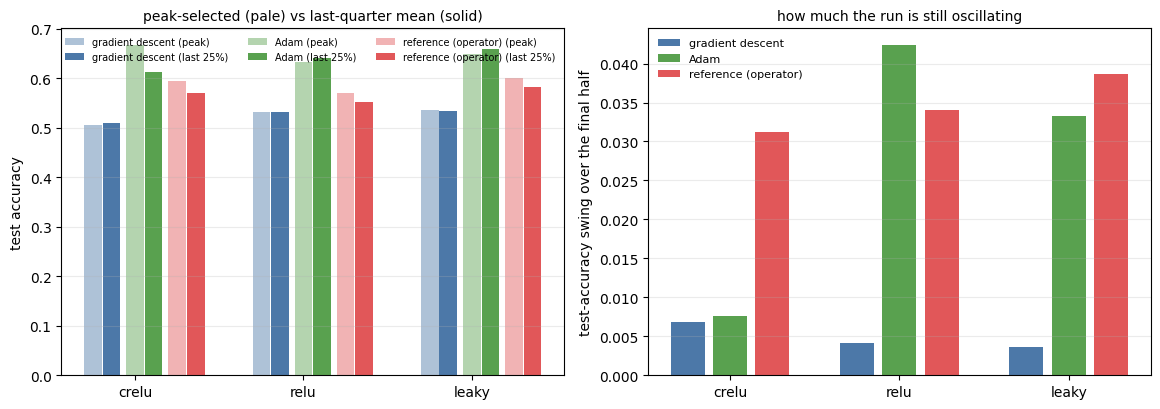

In [3]:
fig = analysis.fig_selection_bias(runs); save(fig, 'selection_bias'); plt.show()

In [4]:
print(f"{'arch':>6} {'arm':>5} | {'stable-selected':>24} | {'peak-selected':>22}")
print(f"{'':>6} {'':>5} | {'hyper':>7} {'test':>7} {'swing':>7} | {'hyper':>7} {'test':>7} {'swing':>6}")
for arch in ['crelu','relu','leaky']:
    for arm in ARMS:
        gs = pick(runs, arch, arm, width=128, steps=12000, by='stable')
        gp = pick(runs, arch, arm, width=128, steps=12000, by='val')
        if not gs: continue
        hs,gsr = gs; hp,gpr = gp
        f = lambda g: (np.mean([stable_test(r) for _,r,_ in g]), np.mean([swing(r) for _,r,_ in g]))
        ts,ss = f(gsr); tp,sp = f(gpr)
        flag = '  <-- different hyper' if abs(hs-hp)>1e-12 else ''
        print(f'{arch:>6} {arm:>5} | {hs:>7g} {ts:>7.3f} {ss:>7.3f} | {hp:>7g} {tp:>7.3f} {sp:>6.3f}{flag}')
    print()

  arch   arm |          stable-selected |          peak-selected
             |   hyper    test   swing |   hyper    test  swing
 crelu    gd |    0.03   0.511   0.007 |    0.03   0.511  0.007
 crelu  adam |   0.003   0.613   0.008 |   0.003   0.613  0.008
 crelu    op |      10   0.571   0.031 |     0.5   0.559  0.033  <-- different hyper

  relu    gd |     0.1   0.532   0.004 |     0.1   0.532  0.004
  relu  adam |   0.003   0.641   0.042 |    0.01   0.520  0.318  <-- different hyper
  relu    op |     0.5   0.553   0.034 |     0.5   0.553  0.034

 leaky    gd |     0.1   0.533   0.004 |     0.1   0.533  0.004
 leaky  adam |   0.003   0.660   0.033 |   0.003   0.660  0.033
 leaky    op |       1   0.583   0.039 |       1   0.583  0.039



**Result.** On ReLU, Adam at $\mathrm{lr}=10^{-2}$ swings by **0.318** in test accuracy and
never drives its training loss below 0.68. Peak selection reports 0.645 for it; the last-quarter
mean reports 0.520.

**Conclusion.** All results below select and score with the last-quarter mean, and report the swing
so an unconverged run is visible. **Three separate findings reported earlier were artefacts of the
peak selector** and are corrected in Part 5: the "operator arm wins on ReLU" claim, "Adam prunes
58% of its units", and the operator rank of Adam (1.13, actually 2.09).

**Headline comparison, corrected:** gradient descent $<$ reference $<$ Adam in all three
architectures. Adam at 0.61--0.66 is at roughly the published MLP level (0.68); the reference at
0.55--0.58 is below it.

---
# Part 1 --- Does the machinery measure what it claims?

## 1.1 Validation against a known closed form

**Motivation.** Every later measurement is built from the contexts and the step map. They must
first reproduce something known analytically.

**Setup.** Balanced chain with a prescribed non-flat spectrum, $L \in \{2,4,8,16,32\}$, deep
linear and CReLU, float64 on CPU. Measure the mode gain $c_k = \sum_\ell \|A_\ell^\top u_k\|^2
\|B_\ell v_k\|^2$ and fit $\log c_k$ against $\log s_k$.

**Result.** Slope $= 2-2/L$ and intercept $= L$ to $10^{-14}$ at every depth, in both
implementations --- reproducing Arora et al. (2018).

**Conclusion.** The contexts, transfer operator and gain measurement are correct. Two traps worth
recording: $c_k$ must be probed with the rank-one direction $u_kv_k^\top$ (a random probe gives a
qualitatively wrong exponent), and a balanced chain is not an orthogonal one (an orthogonal chain
has a flat spectrum, from which no exponent is identifiable).

## 1.2 Structural identities, verified numerically

**Motivation.** Three algebraic facts underpin the interpretation and should be checked in code,
not assumed.

**Result.**
- $\Delta W^{\mathrm{GD}} \propto M^\top \Delta_\star$ is exactly the $k{=}1$ Krylov iterate:
  measured $\cos = 1.000000$ for all four architectures.
- $\Delta W^{\mathrm{ref}} = -\eta (M^\top M)^{+}\nabla_W\mathcal L$: agreement to $10^{-12}$.
  The reference *is* a preconditioned gradient step.
- For deep linear on **whitened** inputs it coincides exactly with Gauss--Newton / the natural
  gradient of Bernacchia et al. ($\cos = 1.000000$), and separates otherwise (0.881 raw inputs,
  0.388--0.690 for ReLU).

**Conclusion.** The construction is not new as a *family*; what is new is the **target** (the
operator rather than the output) and the exact multi-layer solve. This is stated in the paper
rather than glossed.

## 1.3 A solver failure worth recording

**Motivation.** Reachability $\alpha = \|\Pi\Delta_\star\|/\|\Delta_\star\|$ is a projection
ratio, so $\alpha > 1$ is impossible and acts as a free correctness check.

**Result.** Three of eight cells initially returned $\alpha > 1$ with normal-equation residuals of
28, 54 and 552. Cause: LSQR **diverges after it converges** --- the iterate drifts into $\ker M$,
and it does so most where the null space is largest. Measured nullity at $L{=}6$, width 8: 19%
CReLU, 53% ReLU, **83% deep linear, 93% FGLN**.

**Conclusion.** The solve is least reliable on the *simplest* models, the reverse of the natural
suspicion --- and the architectures Part 2 rests on are the best conditioned. Fixed with Tikhonov
damping plus float64 diagnostics: all 44 probes now satisfy $\alpha \le 1$ with residuals
$\sim10^{-10}$. Two natural stopping tests fail here and should not be used: LSQR's internal
`phibar` is monotone by construction, and $\|M\Delta W - \Delta_\star\|$ is blind to $\ker M$
drift (measured: $\|\Delta W\| = 2.9\cdot10^9$ with the residual unchanged to 7 digits).

**The same failure lives in the training path, and this is where it matters.** The fix above went
into `gpu.solve_min_norm`, which the alignment *probe* uses. The *operator arm itself* calls
`gpu.op_step`, which is deliberately undamped and truncated at $k$ --- $k$ is the bias dial, so
that solve is not supposed to converge. The consequence is that its quality is **not monotone in
$k$**. Measured at $L{=}2$, width 128:

| $k$ | 50 | 200 | 1000 | 2000 | 3000 |
|---|---|---|---|---|---|
| $\cos$ against a converged reference | 0.996 | 1.0000 | 1.0000 | 0.614 | 0.563 |
| $\|\Delta W\|$ | 0.81 | 0.85 | 0.85 | $7.9\times10^{13}$ | $9.3\times10^{13}$ |
| operator residual | 1.657 | 1.655 | 1.655 | 2.122 | 2.290 |

Past convergence the step acquires null-space components of magnitude $10^{13}$ that cost almost
nothing in the residual LSQR minimises and ruin the step actually taken. Every result in this
report uses $k \le 200$ and sits below the threshold, but nothing in the code said so, so a later
sweep at larger $k$ would have returned a silently ruined step. `op_step` now raises when
$\|\Delta W\|$ exceeds $10^6$ times the target norm, on the same principle as the exact-ALS
dimension guard: a method's limits belong in the code rather than in the reader's memory.

---
# Part 2 --- What each optimiser does at the step level

## 2.1 Deflection: how much of the request does each step deliver?

**Motivation.** The measurement the framework exists for, and the one endpoint studies cannot make:
score every candidate from the **same weights**, so no difference is attributable to the arms having
drifted apart.

**Setup.** Teacher--student regression, $L{=}8$, width 32, batch 100; 4 architectures $\times$ 2
initialisations, 11 probes per cell along a 1000-step Adam trajectory. Reported quantities are
cosines, hence **scale-invariant and independent of the learning rate**.

In [5]:
print(f"{'arch':>7} {'init':>13} | {'alpha':>6} | {'gd':>7} {'adam':>7} | {'op k=5':>7} {'k=20':>6} {'k=50':>6}")
import json, glob, os
ok=[]
for f in sorted(glob.glob('../runs/theory/probe_*.json')):
    if 'steps' in os.path.basename(f): continue
    d=json.load(open(f)); rows=[x for x in d['rows'] if x['step']>0 and x['alpha']<=1.0 and x['solve_ne']<1e-2]
    if not rows: continue
    g=lambda k: np.nanmean([x[k]['cos_op'] for x in rows])
    al=np.mean([x['alpha'] for x in rows]); ok.append((g('gd'),g('adam'),g('op5'),g('op20'),g('op50')))
    print(f"{d['args']['arch']:>7} {d['args']['init']:>13} | {al:>6.3f} | {g('gd'):>7.3f} {g('adam'):>7.3f} "
          f"| {g('op5'):>7.3f} {g('op20'):>6.3f} {g('op50'):>6.3f}")
a=np.array(ok)
print(f"\n  mean over {len(ok)} cells: gd {a[:,0].mean():+.3f}  adam {a[:,1].mean():+.3f}  "
      f"k=5 {a[:,2].mean():.3f}  k=20 {a[:,3].mean():.3f}  k=50 {a[:,4].mean():.3f}")
print(f"  adam negative in {int((a[:,1]<0).sum())}/{len(ok)} cells; gd positive in {int((a[:,0]>0).sum())}/{len(ok)}")

   arch          init |  alpha |      gd    adam |  op k=5   k=20   k=50
  crelu  looks_linear |  0.438 |   0.358  -0.070 |   0.555  0.745  0.871
  crelu        xavier |  0.375 |   0.284  -0.087 |   0.508  0.752  0.876
   fgln    orthogonal |  0.089 |   0.444   0.010 |   0.808  0.927  0.938
   fgln        xavier |  0.089 |   0.412   0.007 |   0.769  0.875  0.896
 linear    orthogonal |  0.109 |   0.583  -0.032 |   0.896  0.994  0.999
 linear        xavier |  0.113 |   0.515  -0.025 |   0.815  0.943  0.964
   relu    orthogonal |  0.251 |   0.410  -0.239 |   0.582  0.815  0.913
   relu        xavier |  0.224 |   0.323  -0.127 |   0.530  0.799  0.903

  mean over 8 cells: gd +0.416  adam -0.070  k=5 0.683  k=20 0.856  k=50 0.920
  adam negative in 6/8 cells; gd positive in 8/8


**Result.** Reachability is 0.09--0.44 in this configuration (teacher--student, width 32, batch
100): only that fraction of what the loss asks is achievable by *any* update. Gradient descent
realises ~0.42 of the reachable part (positive in 8/8 cells); **Adam is at or below zero in 6/8**;
truncation recovers it, 0.68 → 0.86 → 0.92 for $k = 5,20,50$.

**On $\alpha$ specifically.** Reachability is a property of the architecture, the weights and the
**batch-to-capacity ratio**, not of the optimiser. At the reference configuration (width 128, batch
100) the model is over-parameterised relative to the batch, $M$ is surjective, and $\alpha = 1.000$
for *every* arm including Adam. $\alpha$ therefore **does not separate the arms** and should not be
read as a diagnostic of an optimiser.

**Conclusion --- the paper's central negative result.** *Adam is the least faithful arm at the
operator level and generalises best; the reference is the most faithful and generalises worse.*
Operator-level faithfulness does not explain the implicit bias.

## 2.2 Both spaces, and the cross-arm comparison

**Motivation.** A step can reach the right operator change by a different route through weight
space, because any element of $\ker M$ may be added without changing the function. Recording both
$\cos_{op}$ and $\cos_{w}$ asks whether that happens.

**Setup.** Along each arm's own free-running trajectory at the reference configuration, scoring
gd's and Adam's steps as well, all against the **converged whole-batch** reference. Probes with
solve residual $> 10^{-2}$ are discarded.

In [6]:
for arch in ['crelu','relu']:
    print(f'\n {arch}   cos_w vs the converged reference (cos_op in brackets)')
    print(f"   {'driving':>20} | {'gd step':>18} {'adam step':>18}")
    for arm in ARMS:
        got = pick(runs, arch, arm, width=128, steps=12000, by='stable')
        if not got: continue
        h,g = got; al=[]
        for c,r,d in g: al += [x for x in r if 'gd_cos_w' in x and x['step']>0 and x['solve_ne']<1e-2]
        if not al: continue
        f=lambda k: np.nanmean([x[k] for x in al])
        print(f"   {LABEL[arm]:>20} | {f('gd_cos_w'):>8.3f} ({f('gd_cos_op'):+.3f}) "
              f"{f('adam_cos_w'):>8.3f} ({f('adam_cos_op'):+.3f})")


 crelu   cos_w vs the converged reference (cos_op in brackets)
                driving |            gd step          adam step
       gradient descent |    0.266 (+0.251)    0.204 (+0.247)
                   Adam |    0.109 (+0.094)    0.061 (+0.082)
   reference (operator) |    0.121 (+0.149)    0.115 (+0.135)

 relu   cos_w vs the converged reference (cos_op in brackets)
                driving |            gd step          adam step
       gradient descent |    0.123 (+0.231)    0.097 (+0.215)
                   Adam |    0.016 (+0.357)    0.006 (+0.222)
   reference (operator) |    0.060 (+0.214)    0.060 (+0.216)


**Result.** $\Delta W_{adam}$ is close to orthogonal to $\Delta W^{\mathrm{ref}}$ wherever
evaluated (0.016--0.061 on its own trajectory) and consistently more so than $\Delta W_{gd}$.

**Conclusion.** Adam differs from the reference in *both* components --- it is not "the same
direction plus something extra".

**A caveat on reading the `op` row.** Its own $\cos_w$ is 0.38--0.50, not 1, purely because the
*arm* takes a $k{=}50$ truncated step while the *diagnostic* solves to convergence. The two coincide
exactly as $k$ grows ($\cos_w \to 1.0000$ by $k\approx1000$), and $\cos_{op}$ converges much
faster than $\cos_w$ --- the unreached Krylov directions lie near $\ker M$.

## 2.3 Decomposition: range $(M^\top)$ versus $\ker M$

**Motivation.** Every update splits orthogonally into a part that moves the operator and a part that
does not. The second is invisible to the loss now but reshapes the contexts, and hence the geometry
available later.

**Result (structural, verified).** Gradient descent and the reference lie **entirely** in
range$(M^\top)$ by construction --- measured $\mathrm{ker\_frac} = 0.0000$ for both. **Adam has a
~16% $\ker M$ component**, components orthogonal to machine precision
($0.9869^2 + 0.1612^2 = 1.0000$).

**Conclusion, and a limitation.** Adam is the only arm that moves in function-invisible directions.
But because the other two are identically zero by construction, this cannot be correlated with
generalisation *across* arms --- only *within* Adam, across learning rates. It is a weaker handle
than it first appeared.

## 2.4 What Adam's step does instead

**Motivation.** $\cos_{op}\approx 0$ is a negative statement. This asks the positive one: score
candidate steps against $\Delta_\star$ (what the loss asked) **and** against $P$ itself (pure
rescaling of the operator already present). `sign` is the sign-normalised step, Adam's limit when
the second moment tracks the first.

In [7]:
import json
print(f"{'arch':>6} {'driving':>7} | {'grad vsD*':>10} {'resc':>6} | {'sign vsD*':>10} {'resc':>6} | {'ref vsD*':>9}")
for arch in ['crelu','relu']:
    for arm in ARMS:
        sub=[(c,r,d) for c,r,d in select(runs,arch=arch,arm=arm)
             if analysis.posthoc_rows(d) and 'grad_vs_Dstar' in analysis.posthoc_rows(d)[-1]]
        if not sub: continue
        byh={}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c),[]).append((c,r,d))
        bh=max(byh,key=lambda k: np.mean([stable_test(r) for _,r,_ in byh[k]]))
        ph=[]
        for c,r,d in byh[bh]: ph += [x for x in analysis.posthoc_rows(d) if 'grad_vs_Dstar' in x and x['step']>0]
        f=lambda k: np.nanmean([x[k] for x in ph])
        print(f"{arch:>6} {arm:>7} | {f('grad_vs_Dstar'):>10.3f} {f('grad_rescale_frac'):>6.3f} "
              f"| {f('sign_vs_Dstar'):>10.3f} {f('sign_rescale_frac'):>6.3f} | {f('ref_vs_Dstar'):>9.3f}")
    print()

  arch driving |  grad vsD*   resc |  sign vsD*   resc |  ref vsD*
 crelu      gd |      0.261  0.014 |      0.254  0.020 |     1.000
 crelu    adam |      0.058  0.022 |      0.067  0.102 |     0.998
 crelu      op |      0.244  0.659 |      0.232  0.706 |     0.999

  relu      gd |      0.207  0.015 |      0.197  0.019 |     1.000
  relu    adam |      0.187  0.071 |      0.098  0.326 |     0.838
  relu      op |      0.134  0.261 |      0.128  0.302 |     1.000



**Result.** The reference scores $1.000$ against $\Delta_\star$ wherever the solve converges ---
the internal consistency check the apparatus rests on. Gradient-like steps spend 1--2% of their
operator effect on pure rescaling along gd's path but **26--71% along the reference's path**.

**Conclusion, with a correction.** An earlier single-point measurement supported "Adam rescales
rather than redirects". Across trajectories the honest statement is different: *gradient-like steps
become rescaling-dominated at the points the reference visits*, which is a property of location, not
of the update rule. The one exception is ReLU/Adam at 0.212, the cell where $\alpha$ collapsed to
0.23 --- having moved somewhere with little capacity, the network can no longer express what the
loss asks.

---
# Part 3 --- What they converge to

## 3.1 Endpoints

**Motivation.** Does the per-step deflection accumulate into a different solution?

**Setup.** Free-running arms at the reference configuration, compared at **matched training loss**
(not matched steps, which would measure speed). Effective rank is the participation ratio
$(\sum_i\sigma_i)^2/\sum_i\sigma_i^2$ of $P(x)$, averaged over inputs with $P(x)\neq 0$.

In [8]:
for arch in ['crelu','relu']:
    print(f'\n {arch}')
    for lev in [0.1, 0.05, 0.01]:
        line=f'  train={lev:<6}'
        for arm in ARMS:
            v=[(analysis.at_train_loss(r,lev,'test_acc'), analysis.at_train_loss(r,lev,'pr'))
               for c,r,d in select(runs,arch=arch,arm=arm) if c['width']==128 and c['steps']==12000]
            v=[x for x in v if x[0] is not None]
            line += f'  {arm}: acc {np.mean([x[0] for x in v]):.3f} PR {np.mean([x[1] for x in v]):.2f} (n={len(v)})' if v else f'  {arm}: --'
        print(line)


 crelu
  train=0.1     gd: acc 0.484 PR 6.44 (n=15)  adam: acc 0.578 PR 4.50 (n=12)  op: acc 0.525 PR 7.31 (n=52)
  train=0.05    gd: acc 0.487 PR 6.42 (n=15)  adam: acc 0.588 PR 4.15 (n=12)  op: acc 0.531 PR 7.25 (n=52)
  train=0.01    gd: acc 0.498 PR 6.45 (n=10)  adam: acc 0.576 PR 4.34 (n=11)  op: acc 0.543 PR 7.09 (n=51)

 relu
  train=0.1     gd: acc 0.484 PR 5.78 (n=20)  adam: acc 0.566 PR 3.65 (n=15)  op: acc 0.502 PR 7.39 (n=31)
  train=0.05    gd: acc 0.487 PR 5.80 (n=20)  adam: acc 0.574 PR 3.64 (n=14)  op: acc 0.512 PR 7.47 (n=30)
  train=0.01    gd: acc 0.501 PR 5.86 (n=15)  adam: acc 0.574 PR 4.02 (n=10)  op: acc 0.524 PR 7.41 (n=29)


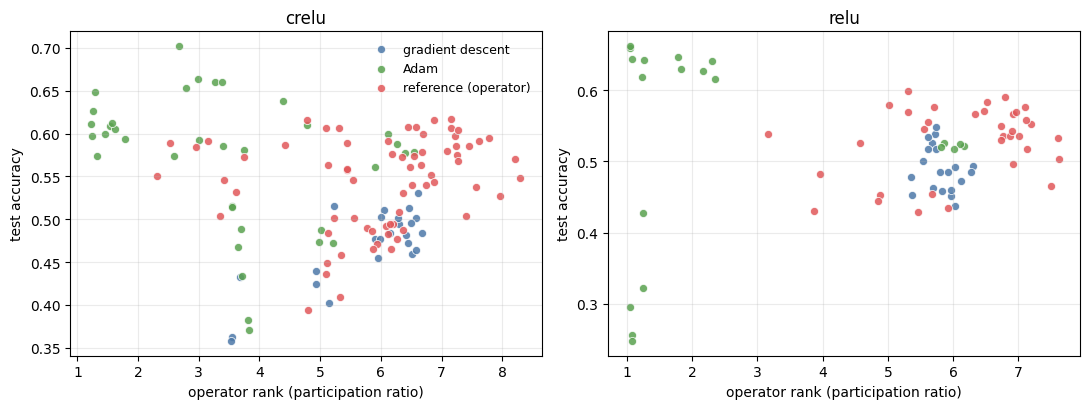

In [9]:
fig = analysis.fig_rank_vs_accuracy(runs) if hasattr(analysis,'fig_rank_vs_accuracy') else analysis.fig_rank_vs_acc(runs)
save(fig, 'rank_vs_accuracy'); plt.show()

**Result.** Adam reaches the lowest operator rank (2.1--3.9) and the best accuracy; gd and the
reference sit at 5.7--6.8.

**Conclusion.** Rank is the one measure on which gd and the reference look alike and Adam differs,
so it is our only candidate for the gd-vs-Adam gap --- but the reference breaks it, having gd-like
rank and intermediate accuracy. No single measure orders all three arms by generalisation.

## 3.2 Fitting versus generalising

**Motivation.** Is the reference "better at learning the training set", or is that irrelevant?

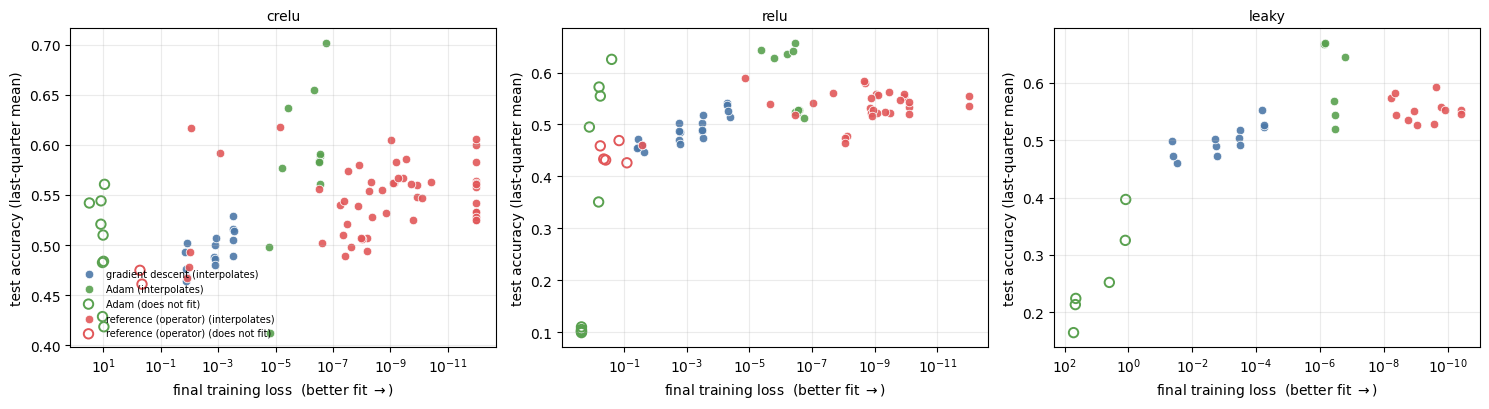

In [10]:
fig = analysis.fig_fit_vs_generalise(runs); save(fig, 'fit_vs_generalise'); plt.show()

**Result.** Two regimes. Below interpolation (gd at small lr, Adam when it diverges), fitting
better helps. Above it --- every operator run and every well-tuned Adam run interpolates at 100%
training accuracy --- further loss reduction buys nothing. The reference drives the loss ~3 orders
lower than Adam (1e-10 vs 1e-7) and gains nothing for it.

**Conclusion.** The reference is an excellent optimiser of a loss that is already effectively zero.
Within the interpolating regime the *least* converged runs generalise best (operator arm: $\eta$=0.1
gives loss 0 and 0.538; $\eta$=10 gives loss 5.7e-08 and 0.571).

## 3.3 k-NN as a reference point

**Motivation.** An absolute scale for "how good is 0.55?".

In [11]:
acc = toy2d.knn_accuracy(0, ks=(1,3,5,10,20,50))
print('k-NN on MNIST-1D (same split):')
for k,v in acc.items(): print(f'   k={k:>2}: {v:.3f}')
print('\n  logistic 0.32 | gd 0.51-0.53 | k-NN 0.58 | operator 0.55-0.58 | Adam 0.61-0.66 | MLP 0.68 | CNN 0.94')

k-NN on MNIST-1D (same split):
   k= 1: 0.552
   k= 3: 0.529
   k= 5: 0.563
   k=10: 0.580
   k=20: 0.552
   k=50: 0.458

  logistic 0.32 | gd 0.51-0.53 | k-NN 0.58 | operator 0.55-0.58 | Adam 0.61-0.66 | MLP 0.68 | CNN 0.94


**Result.** k-NN reaches 0.552 (k=1) to 0.580 (k=10).

**Conclusion.** **The reference arm generalises at k-NN level.** Gradient descent is *below* it.
Adam is meaningfully above. This is the sharpest available characterisation of what our method
achieves: it interpolates and then generalises about as well as local memorisation does.

---
# Part 4 --- The gates and the partition

Since the operator-level measures do not explain generalisation, the remaining structure is the
combinatorial half of the model: which gates are open, and where the linear regions sit.

## 4.1 How much of the nonlinearity is actually used

**Motivation.** A unit pinned to one side across all inputs supplies **no gating** --- the network
is affine in it. For leaky this matters doubly: a unit stuck on the leak side passes $\alpha z$, a
linear path, so counting only "never positive" units undercounts.

**Setup.** `switching` = fraction of units whose sign pattern is *not constant* over 256 training
inputs; `always_on` / `always_off` are the two constant cases. Final snapshot, stable-selected
hyperparameter.

In [12]:
import torch, exp, posthoc
dev='cuda' if torch.cuda.is_available() else 'cpu'
print(f"{'arch':>6} {'arm':>5} | {'switching':>10} {'always_on':>10} {'always_off':>11} | {'test':>6}")
for arch in ['relu','leaky','crelu']:
    for arm in ARMS:
        got=pick(runs,arch,arm,width=128,steps=12000,by='stable')
        if not got: continue
        h,g=got; vals=[]
        for c,r,d in g:
            s=posthoc.snapshots(d)
            if not s: continue
            Ws=[w.to(dev) for w in torch.load(s[-1][1],map_location=dev,weights_only=False)['Ws']]
            D=exp.mnist1d(c['n_train'],c['n_val'],c['n_test'],c['seed'],dev)
            vals.append(posthoc.switching_units(Ws,D['Xtr'][:256],arch))
        if not vals: continue
        f=lambda k: np.mean([v[k] for v in vals])
        te=np.mean([stable_test(r) for _,r,_ in g])
        print(f"{arch:>6} {arm:>5} | {f('switching'):>10.3f} {f('always_on'):>10.3f} "
              f"{f('always_off'):>11.3f} | {te:>6.3f}")
    print()

  arch   arm |  switching  always_on  always_off |   test


  relu    gd |      0.996      0.000       0.004 |  0.532
  relu  adam |      0.912      0.000       0.088 |  0.641
  relu    op |      0.737      0.168       0.095 |  0.553

 leaky    gd |      0.999      0.000       0.001 |  0.533
 leaky  adam |      0.997      0.000       0.003 |  0.660
 leaky    op |      0.758      0.137       0.106 |  0.583

 crelu    gd |      1.000      0.000       0.000 |  0.511
 crelu  adam |      0.998      0.001       0.001 |  0.613
 crelu    op |      0.706      0.148       0.146 |  0.571



**Result.** The **reference arm pins 25--30% of its units** to one side (`always_on` 0.14--0.17
plus `always_off` 0.10--0.15), against $<1$--9% for both baselines, **consistently in all three
architectures**.

**Conclusion, and a correction.** We previously reported the opposite --- "Adam prunes 58% of its
units" --- which came from the peak-selected $\mathrm{lr}=10^{-2}$ run, the diverged one. The
Adam that actually generalises has 8.8% always-off on ReLU and ~0.3% elsewhere. **It is the
reference, not Adam, that under-uses its nonlinearity.**

## 4.2 Does the dead-gate fraction matter for Adam?

**Motivation.** The diverged $\mathrm{lr}=10^{-2}$ run still *peaked* at 0.645 with 58% units
dead. So does the dead fraction matter at all?

In [13]:
print(f"{'lr':>7} | {'always_off':>10} {'switching':>10} | {'peak':>6} {'stable':>7} {'swing':>7} {'final train':>12}")
rows={}
for c,r,d in select(runs,arch='relu',arm='adam'):
    if c['width']!=128 or c['steps']!=12000: continue
    rows.setdefault(c['hyper'],[]).append((c,r,d))
for lr in sorted(rows):
    g=rows[lr]; sw=[]
    for c,r,d in g:
        s=posthoc.snapshots(d)
        if not s: continue
        Ws=[w.to(dev) for w in torch.load(s[-1][1],map_location=dev,weights_only=False)['Ws']]
        D=exp.mnist1d(c['n_train'],c['n_val'],c['n_test'],c['seed'],dev)
        sw.append(posthoc.switching_units(Ws,D['Xtr'][:256],'relu'))
    print(f"{lr:>7g} | {np.mean([x['always_off'] for x in sw]):>10.3f} "
          f"{np.mean([x['switching'] for x in sw]):>10.3f} | "
          f"{np.mean([best_by_val(r)['test_acc'] for _,r,_ in g]):>6.3f} "
          f"{np.mean([stable_test(r) for _,r,_ in g]):>7.3f} "
          f"{np.mean([swing(r) for _,r,_ in g]):>7.3f} "
          f"{np.median([r[-1]['train_loss'] for _,r,_ in g]):>12.2e}")

     lr | always_off  switching |   peak  stable   swing  final train
  0.001 |      0.024      0.962 |  0.522   0.523   0.007     2.84e-07
  0.003 |      0.088      0.912 |  0.632   0.641   0.042     6.24e-07
   0.01 |      0.588      0.411 |  0.645   0.520   0.318     6.31e-01
   0.03 |      0.835      0.159 |  0.310   0.103   0.018     2.30e+00


**Result.** The 58%-dead run *peaks* at 0.645, matching the 8.8%-dead run's 0.632, despite a
6.7$\times$ difference in dead fraction. But dead fraction tracks **swing** perfectly (0.024/0.007
$\to$ 0.588/0.318), and the high-dead run cannot hold its peak (stable 0.520).

**Conclusion.** Dead gates do not determine how good Adam can get; they determine whether it can
*stay* there. Not a lucky run --- consistent across 5 seeds.

## 4.3 Where the linear regions sit

**Motivation.** A ReLU network's linear regions are the sets of inputs sharing a gate pattern.
Humayun et al. (2402.15555) claim they migrate *away* from training samples and *towards* the
decision boundary. Region *count* does not test that; region *placement* does.

**Setup.** A 2D affine plane through three real MNIST-1D training points of different classes ---
the same plane for all arms, so the comparison is of the functions, not the viewpoint. Partition
edges are grid cells where the gate pattern changes.

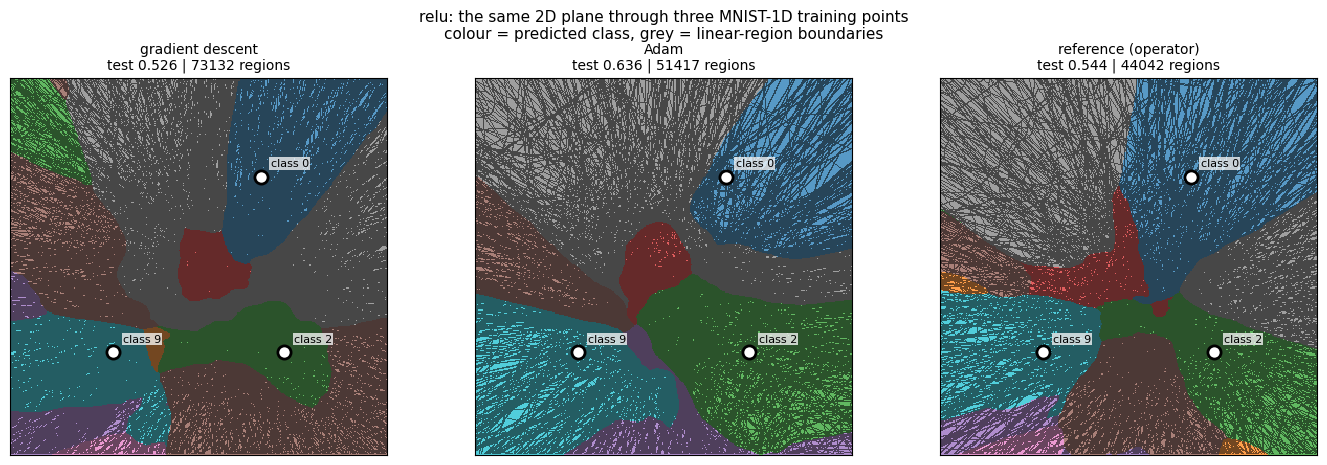

In [14]:
f=toy2d.fig_data_slice(runs,'relu',0); save(f,'slice_relu'); plt.show()

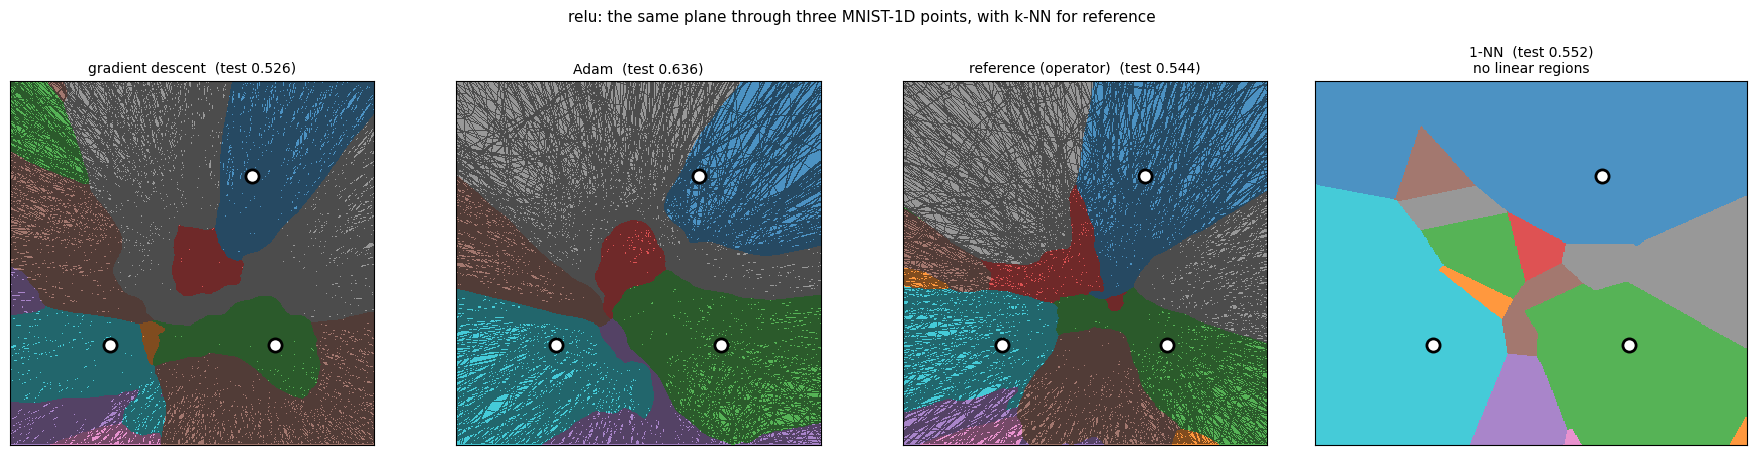

In [15]:
f=toy2d.fig_slice_with_knn(runs,'relu',0,knn_k=1); save(f,'slice_knn1_relu'); plt.show()

**Result (structural).** All three networks produce **radial / conic** regions, because a
bias-free homogeneous net has $f(\lambda x)=\lambda f(x)$ and its decisions are scale-invariant.
1-NN's cells are blobby and data-anchored. The networks use $10^4$--$10^5$ regions on this plane
against 1-NN's handful, and achieve the same accuracy --- a direct visual argument that region
*count* is the wrong quantity.

**Note.** The bias-free constraint the framework requires is itself a strong geometric prior, shared
by all three optimisers. Worth stating in the paper as a limitation of the model class.

## 4.4 Region density versus distance from the data --- and a refuted hypothesis

**Setup.** Partition-edge density binned by distance to the nearest anchor, **averaged over 8
random class-triples $\times$ 3 seeds = 24 planes**, and compared *paired* (same plane) so
plane-to-plane variance cancels.

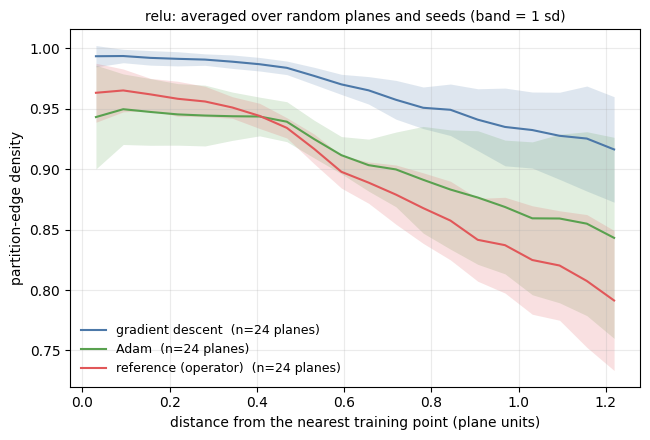

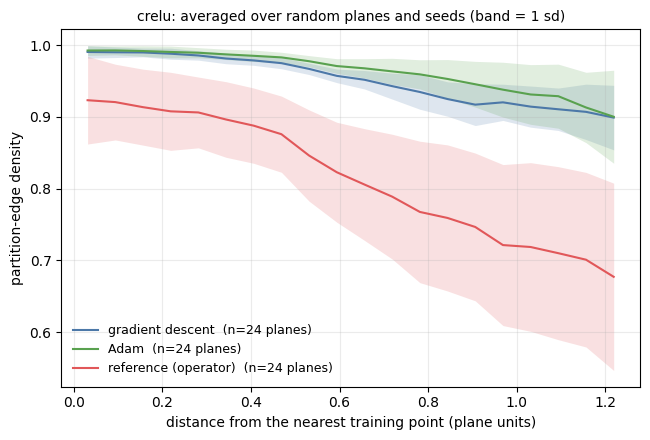

In [16]:
for arch in ['relu','crelu']:
    f=toy2d.fig_complexity_avg(runs,arch,seeds=(0,1,2),n_planes=8)
    save(f,f'complexity_avg_{arch}'); plt.show()

In [17]:
for arch in ['relu','crelu']:
    ctr,cur=toy2d.complexity_curves(runs,arch,seeds=(0,1,2),n_planes=8)
    if len(cur)<3: continue
    C_={a:cur[a][:,0]-cur[a][:,-1] for a in cur}
    print(f'\n {arch}: concentration contrast (density at data - density far away), paired')
    for a,b in (('op','gd'),('op','adam'),('adam','gd')):
        dd=C_[a]-C_[b]; m,s=np.mean(dd),np.std(dd,ddof=1)
        print(f'   {a:>5} - {b:<5}: {m:+.4f} +- {s:.4f}  t={m/(s/np.sqrt(len(dd))):+6.1f}  '
              f'same sign in {100*np.mean(np.sign(dd)==np.sign(m)):.0f}% of planes')


 relu: concentration contrast (density at data - density far away), paired
      op - gd   : +0.0948 +- 0.0573  t=  +8.1  same sign in 96% of planes
      op - adam : +0.0719 +- 0.0855  t=  +4.1  same sign in 88% of planes
    adam - gd   : +0.0228 +- 0.0776  t=  +1.4  same sign in 67% of planes



 crelu: concentration contrast (density at data - density far away), paired
      op - gd   : +0.1547 +- 0.0966  t=  +7.8  same sign in 100% of planes
      op - adam : +0.1538 +- 0.1073  t=  +7.0  same sign in 96% of planes
    adam - gd   : +0.0009 +- 0.0629  t=  +0.1  same sign in 46% of planes


**Result, negative.** Density *decreases* with distance for **all three arms** --- regions are
concentrated **on** the data, the opposite of the migration claim. And the hypothesis "low density
at the data predicts good generalisation" is **refuted**: on CReLU gd and Adam have identical
density at the data ($t=-1.2$) yet differ by 0.10 in accuracy, and the sign of `op - adam` flips
between architectures.

**Result, positive.** What survives is the **concentration contrast**: the reference concentrates
regions on the data about twice as strongly as either baseline (`op - gd` $t=8.1$/$7.8$, same sign
in 96--100% of planes), while **gd and Adam are indistinguishable on it** ($t=0.1$, sign agrees in
46% of planes --- a coin flip).

**Conclusion.** Another measure that separates *our method* from both baselines, pointing the same
way as 4.1: the reference behaves like local memorisation, which is exactly the k-NN-level accuracy
it achieves.

---
# Part 5 --- Interventions

Each of these was designed to test a specific causal hypothesis. **Most came back negative**, and
the negatives are the most useful part of this section: each one removed an explanation we had been
building on.

## 5.1 The bias dial: $k$ from gradient descent to the reference

**Motivation.** $k{=}1$ is *exactly* the gradient descent direction and large $k$ is the reference,
so $k$ interpolates between a biased and an unbiased step. Does correcting the bias help?

**Setup.** $\eta \times k$ grid, $\eta \in \{0.1,...,10\}$, $k \in \{1,2,5,20,50,200\}$,
3 seeds. The $\eta$ axis is essential: at fixed $\eta$, $\|\Delta W\|$ grows ~100$\times$ from
$k{=}1$ to $k{=}200$, so a $k$-only sweep confounds faithfulness with step size.

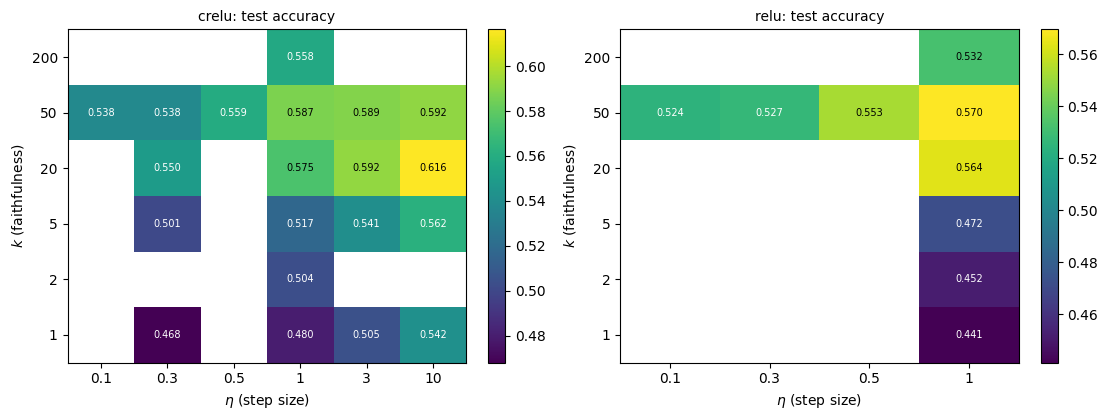

In [18]:
fig = analysis.fig_eta_k_heatmap(runs); save(fig, 'eta_k_heatmap'); plt.show()

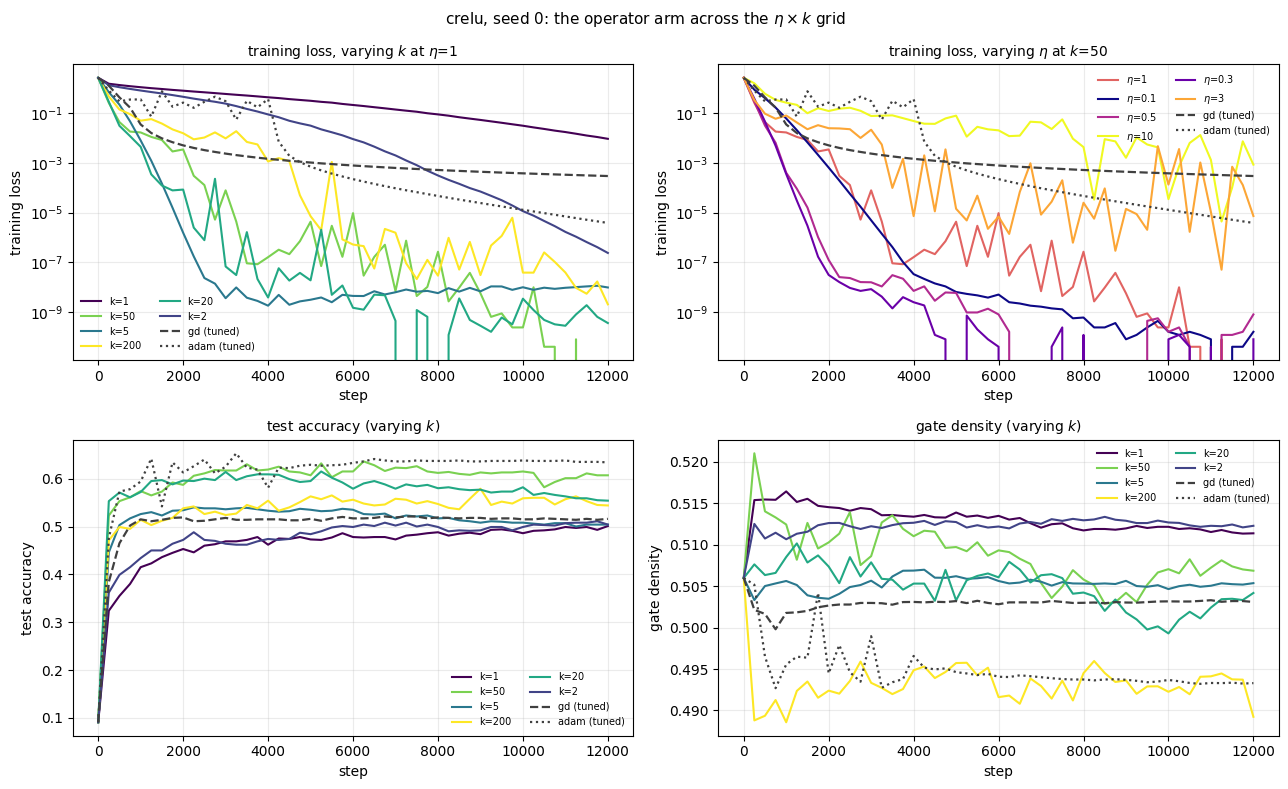

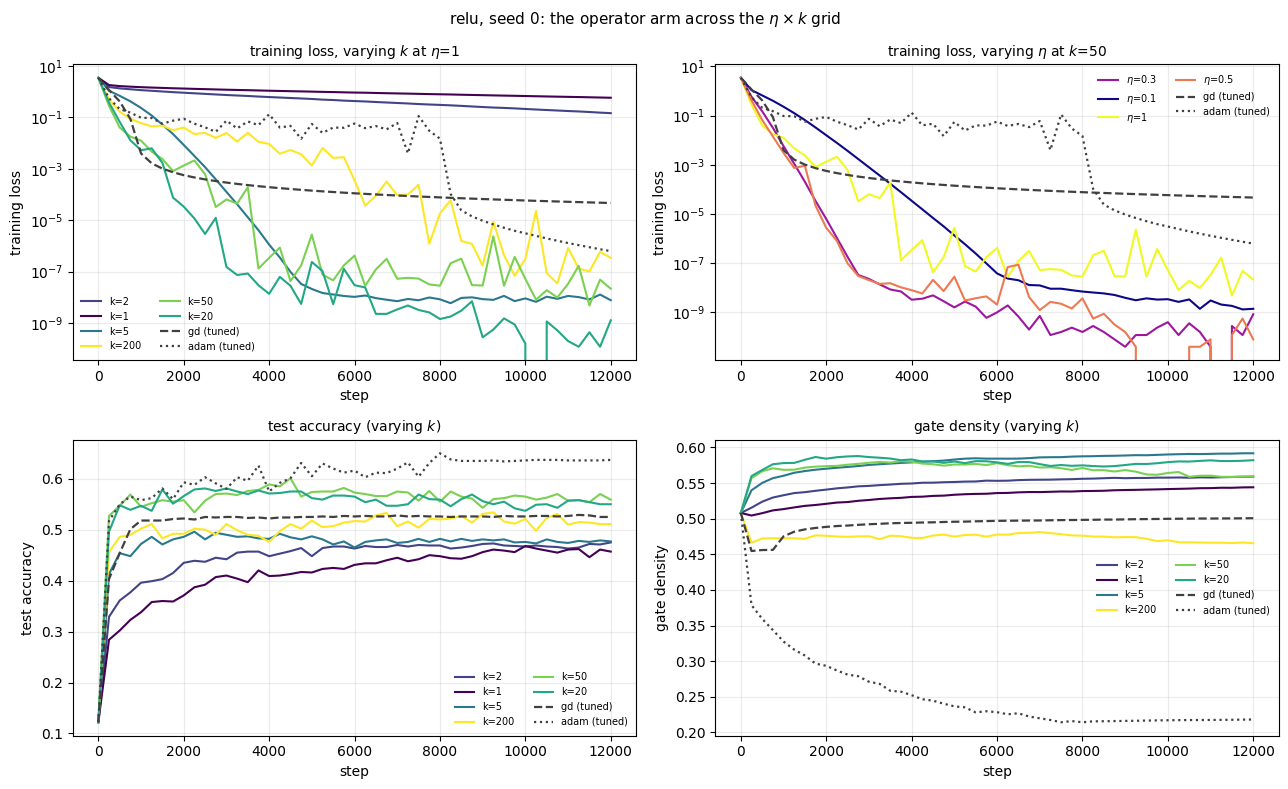

In [19]:
for arch in ['crelu','relu']:
    f=analysis.fig_eta_k_dynamics(runs,arch=arch,seed=0)
    if f is not None: save(f,f'eta_k_dynamics_{arch}'); plt.show()

**Result, withdrawn.** At fixed $\eta{=}1$ the curve looked U-shaped (0.478 at $k{=}1$, peak
0.605 at $k{=}20$, 0.557 at $k{=}200$), suggesting an optimal amount of bias. **This is withdrawn.**
Two controls: it is *not* solver divergence (guarded and unguarded solves agree to
$\cos=1.000000$, residual still falling to $6\cdot10^{-5}$); it *is* step size, and the $k{=}1$ and
$k{=}2$ runs simply never fit (training loss 0.115 and 0.0035).

**Result, corrected.** With $\eta$ tuned per $k$, accuracy is nearly **flat** from $k{=}1$ to
$k{=}50$ (0.608 $\to$ 0.616 on CReLU).

**Conclusion.** Faithfulness contributes ~0.01; step-size normalisation contributes ~0.10. Note this
also means our headline "reference beats gd" is substantially a *normalisation* effect: `op_step`
normalises the target by $\|R\|$ each step while the gd arm uses a fixed learning rate. The
dynamics panels show why: small $\eta$ descends smoothly to $10^{-10}$ and generalises **worst**,
large $\eta$ bounces over orders of magnitude and generalises **best**.

## 5.2 Leaky ReLU

**Motivation.** With gates in $\{\alpha,1\}$ no path is ever annihilated, so leaky was intended to
separate "pruning" from everything else.

In [20]:
print(f"{'arch':>6} {'arm':>5} | {'test':>15} {'op rank':>8} {'always_off':>11} {'switching':>10}")
for arch in ['relu','leaky','crelu']:
    for arm in ARMS:
        got=pick(runs,arch,arm,width=128,steps=12000,by='stable')
        if not got: continue
        h,g=got; sw=[]
        for c,r,d in g:
            s=posthoc.snapshots(d)
            if not s: continue
            Ws=[w.to(dev) for w in torch.load(s[-1][1],map_location=dev,weights_only=False)['Ws']]
            D=exp.mnist1d(c['n_train'],c['n_val'],c['n_test'],c['seed'],dev)
            sw.append(posthoc.switching_units(Ws,D['Xtr'][:256],arch))
        v=[stable_test(r) for _,r,_ in g]
        print(f"{arch:>6} {arm:>5} | {np.mean(v):>7.3f} +-{np.std(v):<5.3f} "
              f"{np.mean([best_by_val(r)['pr'] for _,r,_ in g]):>8.2f} "
              f"{np.mean([x['always_off'] for x in sw]):>11.3f} "
              f"{np.mean([x['switching'] for x in sw]):>10.3f}")
    print()

  arch   arm |            test  op rank  always_off  switching
  relu    gd |   0.532 +-0.010     5.69       0.004      0.996
  relu  adam |   0.641 +-0.010     2.09       0.088      0.912
  relu    op |   0.553 +-0.007     6.83       0.095      0.737

 leaky    gd |   0.533 +-0.013     6.00       0.001      0.999
 leaky  adam |   0.660 +-0.011     3.89       0.003      0.997
 leaky    op |   0.583 +-0.008     6.41       0.106      0.758

 crelu    gd |   0.511 +-0.013     6.57       0.000      1.000
 crelu  adam |   0.613 +-0.070     3.02       0.001      0.998
 crelu    op |   0.571 +-0.029     6.04       0.146      0.706



**Result, and the correction.** We originally reported: leaky removes dead units
(0.578 $\to$ 0.025) and diversity collapse (17.6% $\to$ 83.8%) with accuracy unchanged
(0.645 $\to$ 0.649), concluding that pruning was *dissociable* from Adam's advantage.

**That comparison was invalid** --- it compared the peak-selected ReLU run against the
stable-selected leaky run. Under consistent selection the ReLU contrast is 0.088 $\to$ 0.003, a much
smaller effect, and the clean dissociation disappears.

**Conclusion.** Leaky was testing a hypothesis ("Adam prunes") that was itself a selection artefact.
The intervention is sound; the premise was not.

## 5.3 Capacity: does a *smaller* reference-trained network close the gap?

**Motivation.** If Adam's advantage were capacity self-limitation, handing the reference less
capacity should reproduce it. Widths 16--128, **with Adam at each width as the control**.

**Status.** Partial (50/144 cells before the sweep was paused).

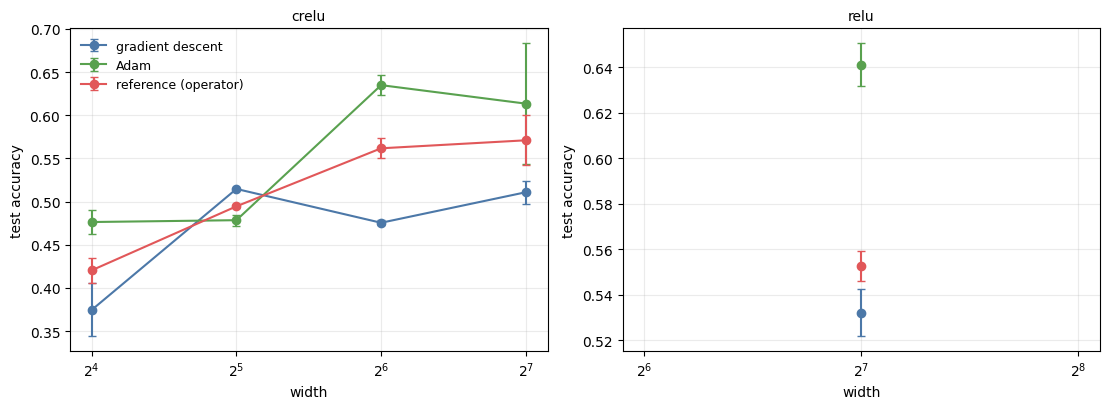

In [21]:
fig = analysis.fig_capacity(runs)
if fig is not None: save(fig, 'capacity'); plt.show()

In [22]:
for arch in ['crelu','relu']:
    ws=sorted({c['width'] for c,_,_ in select(runs,arch=arch)})
    for w in ws:
        row=f'{arch:>6} width {w:>4} | '
        for arm in ARMS:
            got=pick(runs,arch,arm,width=w,steps=12000,by='stable')
            if not got: row+=f'{arm}: --  '; continue
            h,g=got; v=[stable_test(r) for _,r,_ in g]
            row+=f'{arm} {np.mean(v):.3f}+-{np.std(v):.3f} (n={len(v)})  '
        print(row)

 crelu width   16 | gd 0.374+-0.031 (n=3)  adam 0.476+-0.014 (n=3)  op 0.420+-0.015 (n=3)  
 crelu width   32 | gd 0.515+-0.000 (n=1)  adam 0.478+-0.006 (n=3)  op 0.494+-0.001 (n=2)  
 crelu width   64 | gd 0.475+-0.003 (n=2)  adam 0.635+-0.011 (n=2)  op 0.562+-0.011 (n=2)  
 crelu width  128 | gd 0.511+-0.013 (n=5)  adam 0.613+-0.070 (n=5)  op 0.571+-0.029 (n=5)  
  relu width  128 | gd 0.532+-0.010 (n=5)  adam 0.641+-0.010 (n=5)  op 0.553+-0.007 (n=5)  


**Result, early and negative.** At width 16 on CReLU everything drops and **Adam's lead widens**
rather than closing (gd 0.363, operator 0.380, Adam 0.460).

**Conclusion.** No support for capacity self-limitation as the mechanism, on the evidence available.
Incomplete --- treat as indicative.

## 5.4 When is the advantage created? The optimiser-switch experiment

**Motivation.** The sharpest form of the question. If Adam's benefit is established early and merely
preserved, a run that starts with Adam and finishes with the reference should keep it. If the
benefit requires Adam throughout, it should not. Both directions are run because they ask different
things: `adam→op` asks whether the reference can *preserve*; `op→adam` asks whether Adam can
*repair*.

**Setup.** Total budget fixed at 12000 steps; handover at $\{0, 250, 1000, 3000, 6000, 12000\}$;
Adam $\mathrm{lr}=3\cdot10^{-3}$, reference $\eta=0.5$, $k=50$; ReLU and CReLU, 3 seeds, 72 cells.
Handover 0 is the pure second arm and handover 12000 the pure first, so the endpoints reproduce the
unmixed optimisers as an internal check.

**Result (complete, 72/72 cells).** The curves are smooth and monotone in the handover point,
with no critical window --- but the effect is strongly **front-loaded and asymmetric**.

In [23]:
for arch in ['relu','crelu']:
    print(f'\n {arch}   (total budget fixed at 12000 steps)')
    print(f"   {'handover':>9} | {'adam->op  (Adam FIRST)':>24} | {'op->adam  (Adam LAST)':>24}")
    pts={}
    for c,r,d in switch:
        if c['arch']!=arch: continue
        A,hA,B,hB,at = c['hyper']
        pts.setdefault((f'{A}->{B}',at),[]).append(r)
    for at in sorted({k[1] for k in pts}):
        row=f'   {at:>9} | '
        for dr in ('adam->op','op->adam'):
            g=pts.get((dr,at))
            row += (f"{np.mean([stable_test(r) for r in g]):>14.3f} +-{np.std([stable_test(r) for r in g]):<7.3f} | "
                    if g else f"{'--':>24} | ")
        print(row)
    a=pts.get(('adam->op',6000)); b=pts.get(('op->adam',6000))
    if a and b:
        print(f"   equal Adam budget (6000 steps each): FIRST {np.mean([stable_test(r) for r in a]):.3f}"
              f"   LAST {np.mean([stable_test(r) for r in b]):.3f}")


 relu   (total budget fixed at 12000 steps)
    handover |   adam->op  (Adam FIRST) |    op->adam  (Adam LAST)
           0 |          0.548 +-0.004   |          0.645 +-0.009   | 
         250 |          0.554 +-0.010   |          0.636 +-0.011   | 
        1000 |          0.574 +-0.016   |          0.613 +-0.009   | 
        3000 |          0.601 +-0.013   |          0.562 +-0.018   | 
        6000 |          0.606 +-0.008   |          0.547 +-0.011   | 
       12000 |          0.645 +-0.009   |          0.548 +-0.004   | 
   equal Adam budget (6000 steps each): FIRST 0.606   LAST 0.547

 crelu   (total budget fixed at 12000 steps)
    handover |   adam->op  (Adam FIRST) |    op->adam  (Adam LAST)
           0 |          0.561 +-0.000   |          0.596 +-0.070   | 
         250 |          0.581 +-0.005   |          0.640 +-0.014   | 
        1000 |          0.645 +-0.005   |          0.608 +-0.021   | 
        3000 |          0.660 +-0.008   |          0.527 +-0.005   | 
        60

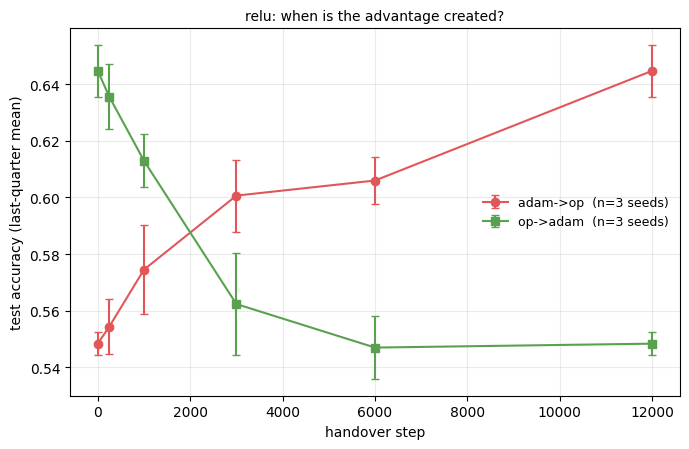

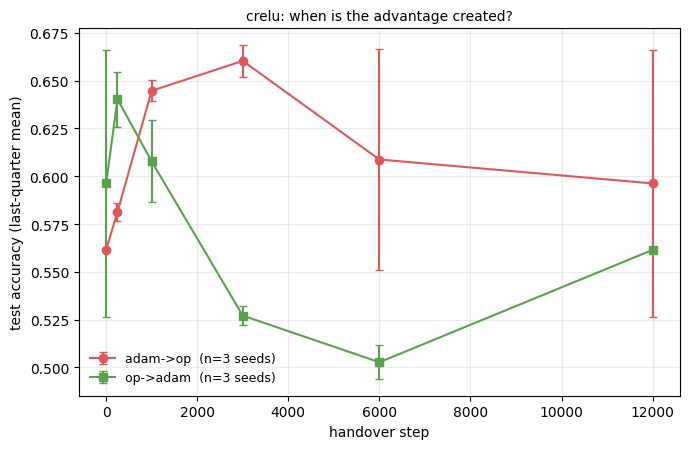

In [24]:
for arch in ['relu','crelu']:
    f=analysis.fig_switch(switch,arch)
    if f is not None: save(f,f'switch_{arch}'); plt.show()

**Conclusion --- the clearest positive result in this report.**

The decisive comparison holds Adam's budget **fixed** at 6000 steps and varies only *when* it runs:

| | Adam first | Adam last |
|---|---|---|
| ReLU | **0.606** | 0.547 |
| CReLU | **0.609** | 0.503 |

Same optimiser, same number of steps, 0.06--0.11 difference from position alone. The asymmetry is
stark in both directions: 3000 reference steps followed by **9000 Adam steps** reaches only 0.562
(ReLU) / 0.527 (CReLU) against 0.645 / 0.596 for pure Adam. **Adam cannot undo what the reference
does early, even with 75% of the budget afterwards.** Conversely, handing over *to* the reference
is cheap --- Adam for 6000 then reference for 6000 gives 0.606, only 0.04 below pure Adam. The
reference can largely *hold* what Adam built; it cannot *build* it.

**On CReLU, the mixture beats both pure arms.** Adam for 3000 steps then the reference for 9000
gives $0.660 \pm 0.008$, above pure Adam ($0.596 \pm 0.070$) and pure reference ($0.561$). It shows
at two adjacent handover points (1000 $\to$ 0.645, 3000 $\to$ 0.660) with tight seed spreads, so it
is unlikely to be noise --- though pure Adam's wide CReLU spread argues for another seed or two
before leaning on it.

**Why this matters more than the structural metrics.** It is a controlled statement that depends on
no summary statistic at all: *the generalisation-relevant work happens early, it is done by a rule
that is not operator-faithful, and no amount of subsequent faithful optimisation recovers it.* It
localises the phenomenon **in time**, which every correlational measure in Parts 3--4 failed to do.

**The question it sharpens:** what does Adam do in the first ~3000 steps that the reference does
not, and why is it irreversible? The gates are the natural place to look, since that is where the
two arms already differ early (Adam's early churn 0.116--0.244 against the reference's
0.052--0.087, Part 4).

## 5.5 Extended training: no grokking, but delayed robustness

**Motivation.** The arms were demonstrably unfinished at 12k steps. Does anything change over
20--80$\times$ longer?

**Setup.** Adam continued from its 12k checkpoint to 300k (and 1M) steps, snapshots every 25k. The
original runs are untouched --- a new config hash, with the checkpoint copied in so it resumes.

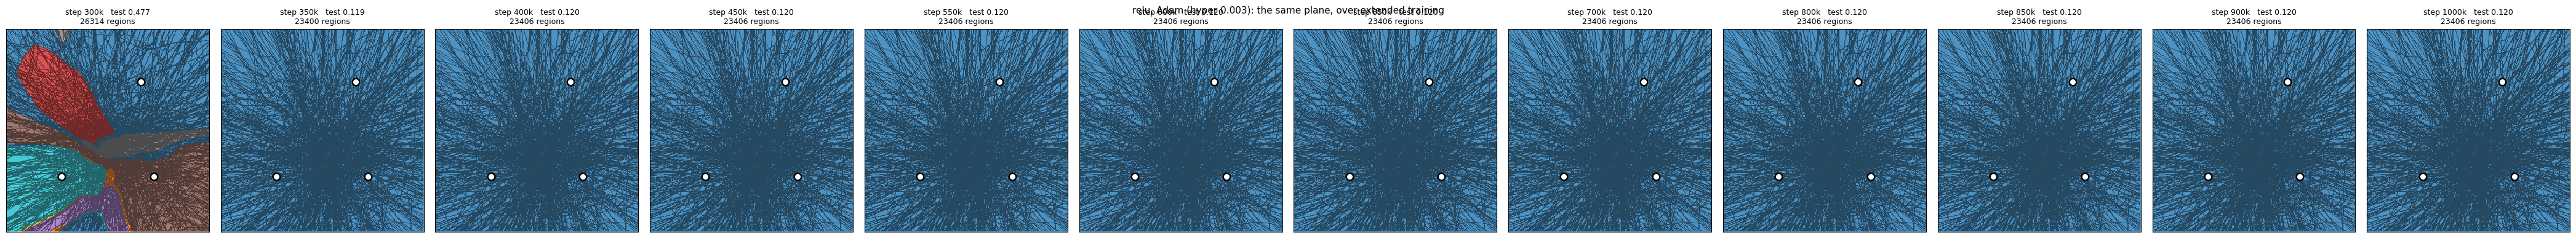

    step    test  regions
  300000   0.477    26314
  350000   0.119    23400
  400000   0.120    23406
  450000   0.120    23406
  550000   0.120    23406
  600000   0.120    23406
  650000   0.120    23406
  700000   0.120    23406
  800000   0.120    23406
  850000   0.120    23406
  900000   0.120    23406
 1000000   0.120    23406


In [25]:
f,st=toy2d.fig_slice_evolution('relu','adam',0,max_panels=12)
if f: save(f,'slice_evolution_adam_relu'); plt.show()
if st:
    print(f'{"step":>8}{"test":>8}{"regions":>9}')
    for s,a,n in st: print(f'{s:>8}{a:>8.3f}{n:>9}')

In [26]:
rb=toy2d.robustness_curve('relu','adam',0,steps_cfg=300000)
if rb:
    print(f'{"step":>8}{"clean":>8}{"PGD 0.1":>9}{"PGD 0.3":>9}')
    for x in rb: print(f'{x["step"]:>8}{x["clean"]:>8.3f}{x["pgd_0.1"]:>9.3f}{x["pgd_0.3"]:>9.3f}')

    step   clean  PGD 0.1  PGD 0.3
   25000   0.639    0.276    0.092
   50000   0.619    0.265    0.075
   75000   0.650    0.353    0.301
  100000   0.660    0.334    0.206
  125000   0.644    0.303    0.167
  150000   0.647    0.312    0.132
  175000   0.625    0.292    0.159
  200000   0.620    0.322    0.123
  225000   0.596    0.315    0.100
  250000   0.630    0.343    0.178
  275000   0.485    0.296    0.222
  300000   0.477    0.324    0.268


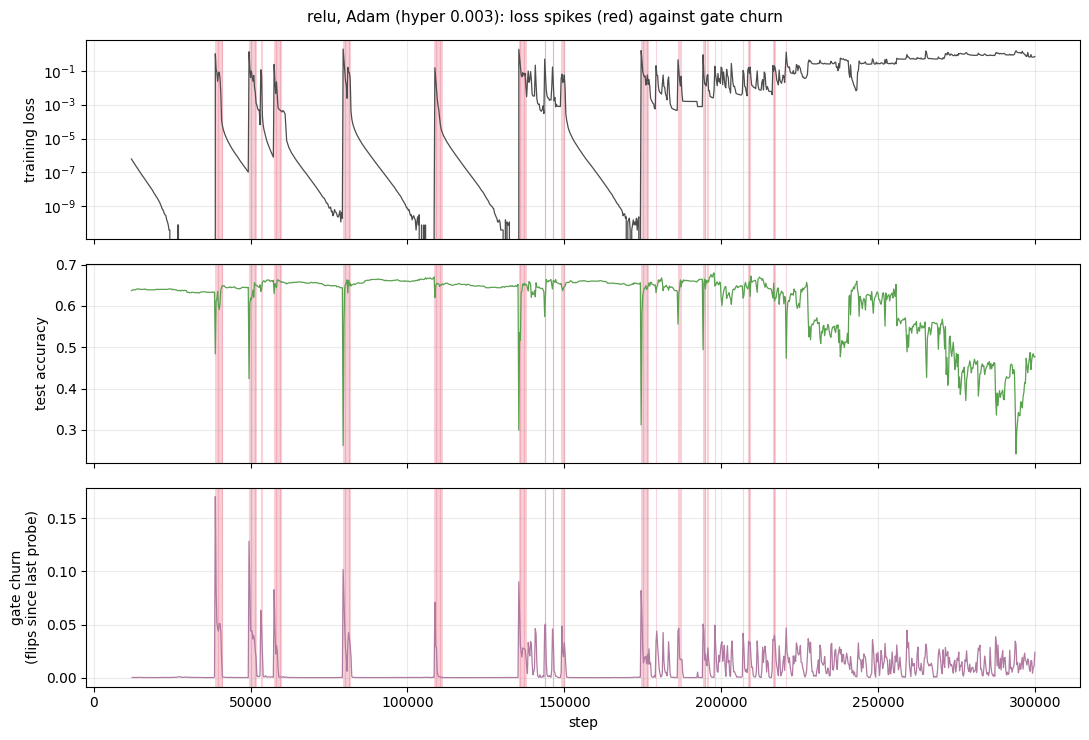

            n_spikes: 104
      churn_at_spike: 0.0348
     churn_elsewhere: 0.0058
        acc_at_spike: 0.6202
       acc_elsewhere: 0.6123


In [27]:
f,stt=toy2d.fig_spikes('relu','adam',0,steps_cfg=300000)
if f:
    save(f,'spikes_adam_relu'); plt.show()
    for k,v in stt.items(): print(f'  {k:>18}: {v:.4f}' if isinstance(v,float) else f'  {k:>18}: {v}')

**Result 1, negative.** No grokking. Clean test accuracy stays in a 0.62--0.66 band across 20$\times$
the original budget, then *falls* to 0.48, and the 1M continuation collapses to chance (0.120,
training loss 2.26 $\approx \ln 10$). Region count falls 43k $\to$ 24k and then **plateaus from
step 150k**, so the simplification does stop --- it just buys no generalisation.

**Caveat on the setup.** We use no weight decay and standard initialisation. Omnigrok (Liu et al.,
ICLR 2023) shows large initialisation *and* weight decay are jointly necessary for classical
grokking, so a null result for *test-accuracy* grokking in this regime is expected and uninformative.

**Result 2, now largely withdrawn --- see 5.7.** *Delayed robustness* appeared clearly: PGD
accuracy at $\epsilon{=}0.3$ rising from 0.073--0.090 early to 0.236--0.258 at the end, increasing
while clean accuracy fell. Those numbers come from a cross-entropy attack, which 5.7 shows fails
against exactly the high-margin networks this run produces (its logit margin reaches 116). Under a
scale-covariant CW attack the effect is weak at $\epsilon{=}0.3$ (0.021 $\to$ 0.098) and **flat at
$\epsilon{=}0.1$** (0.226 $\to$ 0.229). Something may remain at large radius; the dramatic version
does not.

**Result 3, positive.** Loss spikes coincide with gate reorganisation: 104 spikes detected, gate
churn **6$\times$ higher** during them (0.0348 vs 0.0058), with test accuracy *unchanged* across
them (0.620 vs 0.612). These are genuine reorganisation events, not damage --- an independent
replication of the mechanism in Humayun et al. on a different dataset with a different measurement.
Note this is the half of their claim that *does* reproduce here, while the region-migration half
does not (4.4).

**The control that was missing.** Everything above is one arm. Gradient descent and the
reference were then run to the same 300k steps, so the three can be read on shared axes. This is
what makes "Adam restructures throughout training" a claim rather than an observation about Adam
alone.

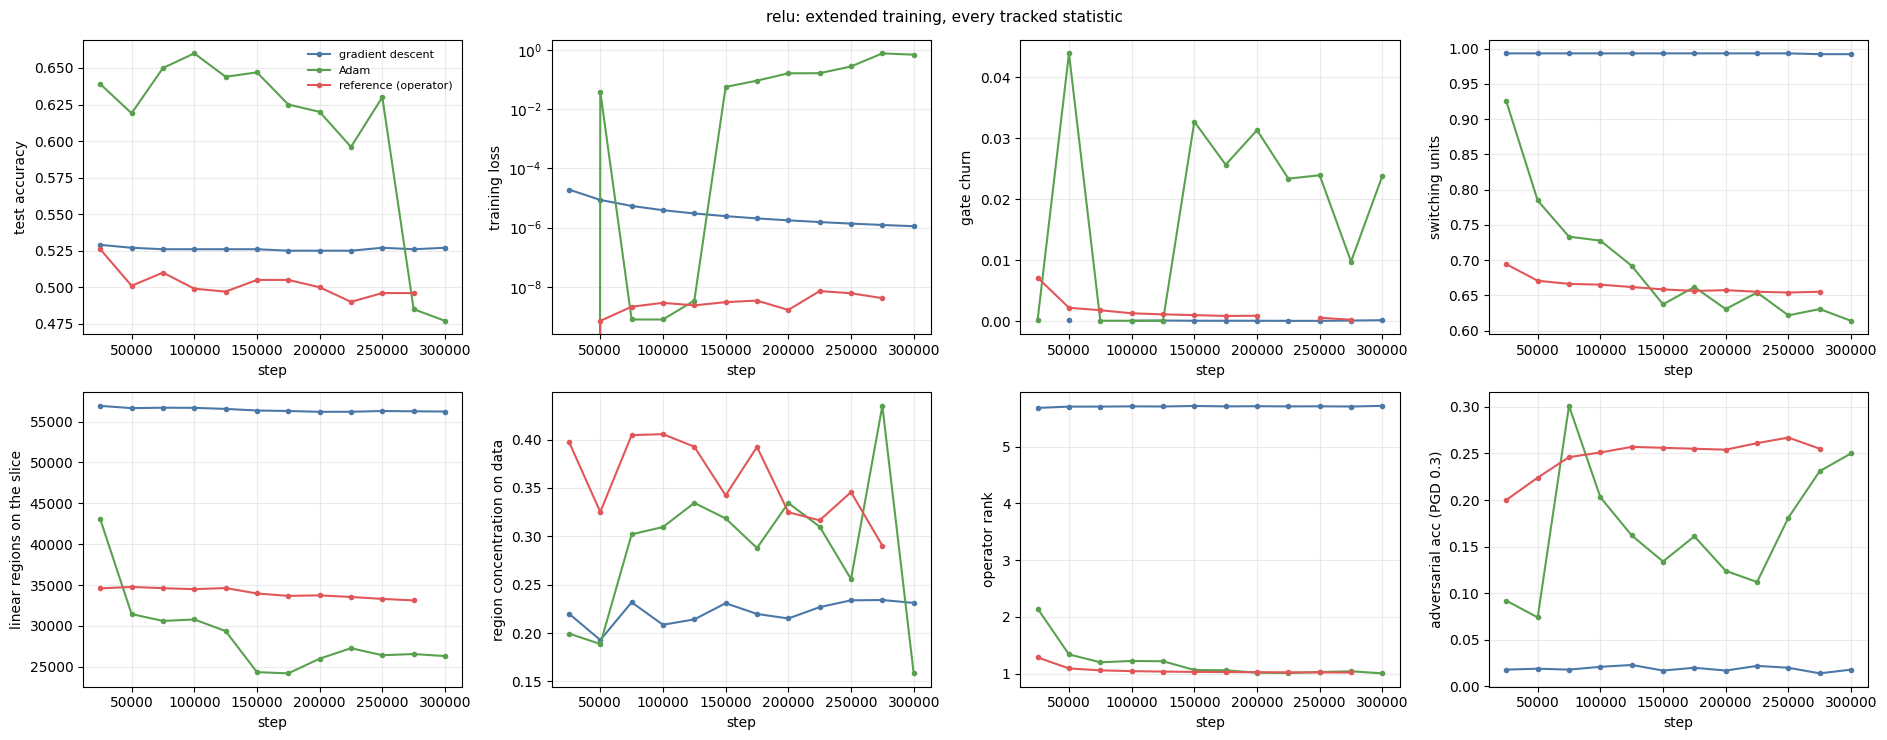

=== gd
    step   test     train  switch  regions    conc   rank  PGD.3
   25000  0.529   1.9e-05   0.993    56915   0.220   5.68  0.018
   75000  0.526   5.4e-06   0.993    56689   0.232   5.71  0.018
  125000  0.526   3.0e-06   0.993    56542   0.214   5.71  0.023
  175000  0.525   2.1e-06   0.993    56289   0.220   5.71  0.020
  225000  0.525   1.5e-06   0.993    56195   0.227   5.71  0.022
  275000  0.526   1.2e-06   0.992    56250   0.234   5.71  0.014
=== adam
    step   test     train  switch  regions    conc   rank  PGD.3
   25000  0.639  -0.0e+00   0.925    43045   0.200   2.14  0.092
   75000  0.650   7.9e-10   0.733    30606   0.302   1.20  0.301
  125000  0.644   3.5e-09   0.692    29370   0.335   1.22  0.162
  175000  0.625   9.2e-02   0.662    24198   0.288   1.06  0.161
  225000  0.596   1.6e-01   0.654    27274   0.310   1.01  0.112
  275000  0.485   7.7e-01   0.631    26559   0.435   1.04  0.231
=== op
    step   test     train  switch  regions    conc   rank  PGD.3
  

In [28]:
f, ext = toy2d.fig_extended('relu', arms=('gd','adam','op'), seed=0, steps_cfg=300000)
if f:
    save(f, 'fig_extended_relu_all'); plt.show()
    for arm, rows in ext.items():
        print(f'=== {arm}')
        print(f'{"step":>8}{"test":>7}{"train":>10}{"switch":>8}{"regions":>9}{"conc":>8}{"rank":>7}{"PGD.3":>7}')
        for r in rows[::2]:
            print(f'{r["step"]:>8}{r["test"]:>7.3f}{r["train"]:>10.1e}{r["switching"]:>8.3f}'
                  f'{r["regions"]:>9}{r["concentration"]:>8.3f}{r["pr"]:>7.2f}{r["pgd"]:>7.3f}')

**Result 4: gradient descent is frozen.** Over 275k steps past convergence, test accuracy
moves 0.529 $\to$ 0.527, linear regions 56.9k $\to$ 56.2k ($-1.2\%$), switching units 0.993 $\to$
0.992, operator rank 5.68 $\to$ 5.72, churn $10^{-4}$. Nothing happens. The reference is nearly as
static (test 0.526 $\to$ 0.496, regions $-4\%$, rank 1.28 $\to$ 1.02, churn decaying to $2\times
10^{-4}$); only Adam keeps restructuring, and it eventually destabilises --- training loss climbs
from $10^{-9}$ to 0.69 while test accuracy falls to 0.477.

So "Adam explores for longer" is real and specific to Adam. But the exploration is not *paying* by
300k steps: Adam's best clean accuracy in the whole extended run (0.660 at 100k) is only 0.02 above
its 12k value, and it is worse by the end.

**Result 5, retracted --- see 5.7.** The adversarial column in the figure appeared to separate
the arms far more sharply than anything in Part 6 (gd pinned near 0.015, the reference at 0.25
from the first snapshot, Adam climbing 0.093 $\to$ 0.260). It is plotted with the cross-entropy
attack and does not survive a scale-covariant one. The `pgd` panel above should be read as a plot
of *logit saturation*, not robustness. It is left in the figure deliberately, next to the
`margin`-driven explanation in 5.7.

## 5.6 Operator momentum: buying unfaithfulness inside the operator family

**Motivation.** Section 5.5's table ends on an uncomfortable reading. Adam is the *least*
operator-faithful arm ($\cos_{op}\approx 0$) and generalises best; the reference is the most
faithful (0.80--0.88) and generalises worse. Taken at face value that suggests *unfaithfulness
itself* is the useful ingredient. But Adam differs from the reference in many ways at once
(per-coordinate scaling, a $\ker M$ component, a different effective step size), so the
comparison cannot isolate faithfulness. This experiment does isolate it: it degrades
faithfulness *inside* the operator family, changing nothing else, and asks whether accuracy
follows.

**The rule.** The reference produces, at each step, the minimum-norm $\Delta W$ whose operator
image matches the requested $\Delta^\star = (-\eta G(x))_x$. Momentum smooths that displacement
directly,

$$u_t \;=\; \beta\,u_{t-1} + (1-\beta)\,\Delta W^{\mathrm{ref}}_t, \qquad W_{t+1} = W_t + u_t ,$$

with **no learning rate**: the operator rule has none, because the step size already enters
through $\eta$ inside $\Delta^\star$. The $(1-\beta)$ factor keeps $\|u_t\|$ on the scale of a
single reference step, so $\beta$ changes the *direction* the step is smoothed towards and not
its magnitude. By construction $\beta = 0$ is the unmodified reference, which makes the
$\beta = 0$ column a bit-for-bit control rather than a nominally-equivalent rerun.

**Why it should hurt faithfulness.** $\Delta W^{\mathrm{ref}}_t$ lies entirely in
$\mathrm{range}(M_t^\top)$ --- that is what $M^+$ returns. But $M_t$ depends on the weights, so
$\mathrm{range}(M^\top)$ *rotates* as training moves. A stale $u_{t-1}$ was faithful at the point
where it was computed and is not at the current one: part of it now lies in $\ker M_t$, where it
moves weights without moving the operator. Larger $\beta$ means staler, so the deflection should
fall monotonically in $\beta$. That is a prediction the sweep can check, and it is the opposite of
what I predicted before running it (I expected momentum to stay faithful).

**Setup.** ReLU and CReLU, width 128, 12k steps, $\eta \in \{0.5, 1\}$, $k = 50$ Krylov
iterations, $\beta \in \{0, 0.5, 0.9, 0.99\}$, seeds 0--2 --- 48 cells. Scored with
`stable_test` (last-quarter mean), the same estimator used for selection everywhere else.


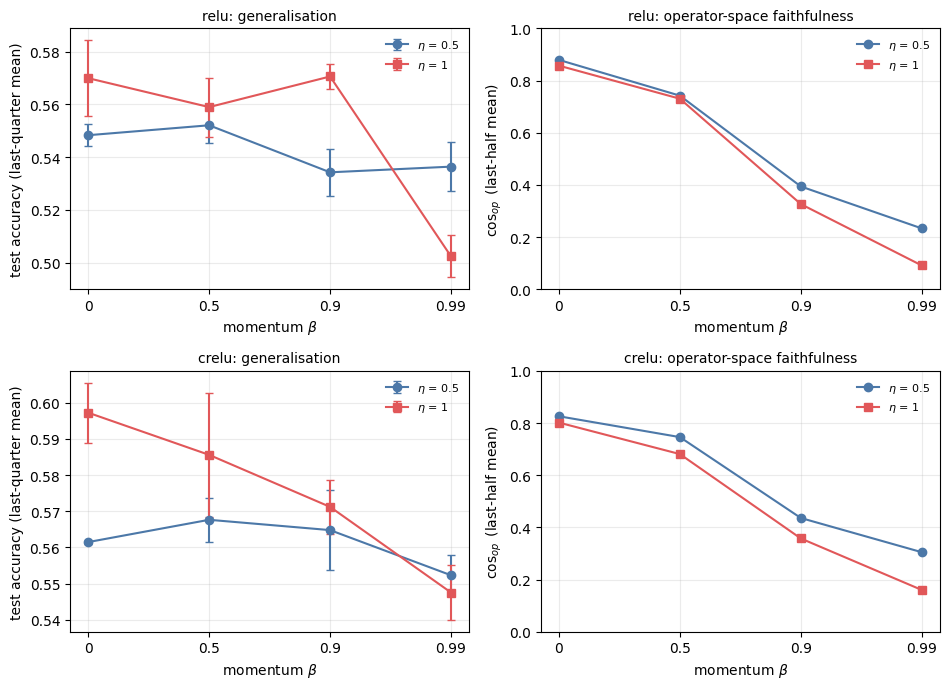

In [29]:
runs = analysis.load('ref_mnist1d')
f = analysis.fig_momentum(runs); save(f, 'fig_momentum'); plt.show()

Paired against the $\beta = 0$ control **on the same seed**, so seed variance cancels:

In [30]:
rows = analysis.momentum_table(runs)
print(f'{"arch":>6}{"eta":>6}{"beta":>7}{"n":>3}{"d(acc) vs b=0":>18}{"cos_op":>9}{"(b=0)":>8}{"train loss":>13}')
for r in rows:
    print(f'{r["arch"]:>6}{r["eta"]:>6g}{r["beta"]:>7g}{r["n"]:>3}'
          f'{r["delta_acc"]:>+11.4f} +-{r["delta_sd"]:<5.4f}'
          f'{r["cos_op"]:>9.3f}{r["cos_op_beta0"]:>8.3f}{r["final_train_loss"]:>13.1e}')

  arch   eta   beta  n     d(acc) vs b=0   cos_op   (b=0)   train loss
  relu   0.5    0.5  3    +0.0038 +-0.0106    0.742   0.879      4.0e-11
  relu   0.5    0.9  3    -0.0141 +-0.0049    0.394   0.879      7.9e-11
  relu   0.5   0.99  3    -0.0119 +-0.0113    0.233   0.879      3.6e-10
  relu     1    0.5  3    -0.0110 +-0.0041    0.730   0.857      1.5e-08
  relu     1    0.9  3    +0.0006 +-0.0107    0.326   0.857      4.3e-09
  relu     1   0.99  3    -0.0676 +-0.0183    0.091   0.857      5.7e-09
 crelu   0.5    0.5  3    +0.0062 +-0.0060    0.746   0.826      4.0e-11
 crelu   0.5    0.9  3    +0.0033 +-0.0107    0.436   0.826      0.0e+00
 crelu   0.5   0.99  3    -0.0092 +-0.0052    0.305   0.826      2.0e-10
 crelu     1    0.5  3    -0.0116 +-0.0091    0.681   0.802      4.0e-11
 crelu     1    0.9  3    -0.0260 +-0.0128    0.357   0.802      0.0e+00
 crelu     1   0.99  3    -0.0496 +-0.0077    0.160   0.802      5.2e-10


**Verification.** All twelve $\beta = 0$ cells reproduce the corresponding plain-reference run
to the last digit of the training loss (e.g. ReLU $\eta{=}1$ seed 2: $1.33\times10^{-5}$ in both),
so the momentum code path is the reference code path when $\beta = 0$.

**What happened.** The faithfulness prediction holds cleanly and monotonically: $\cos_{op}$ falls
from 0.80--0.88 at $\beta = 0$ to 0.09--0.30 at $\beta = 0.99$, and the weight-space alignment
$\cos_w$ falls with it (0.34 $\to$ 0.03 on ReLU). Momentum is an effective dial for
unfaithfulness. The earlier $\ker M$ measurement says where the lost mass goes: the momentum
buffer carries 68--73% of its norm in $\ker M_t$, *more* than Adam's $\approx 16\%$.

**Accuracy does not follow.** No $\beta$ beats the control by more than noise; $\beta = 0.5$ is
$+0.004$ to $+0.006$ on two cells and $-0.011$ on two others. $\beta = 0.99$ costs $-0.05$ to
$-0.07$ where the effect is largest. Every cell still interpolates (final training loss
$\le 10^{-8}$), so this is a generalisation effect and not a failure to fit.

**Why this matters for the story.** It is a within-family control for §5.5's central negative
result. Faithfulness was reduced by an order of magnitude with everything else held fixed --- same
target, same $\eta$, same solver, same seeds --- and generalisation got *worse*, not better. So
the inverse ordering in the table is **not** a causal relationship: being unfaithful is not what
makes Adam good. Whatever Adam does, it is a specific direction of deflection, not deflection as
such. That also rules out the cheapest possible "fix" for the reference, which was worth checking
before proposing anything more elaborate.

**Negative result, recorded.** Operator momentum is not a useful modification of the reference
rule. Its value here is as a control.

## 5.7 Adversarial robustness: a result that did not survive its own control

**Motivation.** The extended run (5.5) appeared to show gradient descent with essentially zero
PGD robustness where the other two arms had 20--26% --- a far larger gap than any measure in
Part 6, running in the direction of the accuracy ordering. This section reports that measurement,
the control that destroyed it, and the corrected picture. It is kept in full because the failure
mode is not specific to us and is not caught by the control everyone runs.

**Definitions.** PGD$_\epsilon$ accuracy is test accuracy under an $L_\infty$ attack of radius
$\epsilon$: 50 steps of size $2.5\epsilon/50$ from a uniform random start in the ball. Two attack
objectives appear below. The **cross-entropy** attack ascends $-\log p_y$. The **CW** attack
ascends the margin $\max_{j \ne y} z_j - z_y$. **Logit margin** is $z_y - \max_{j\ne y} z_j$ on
clean inputs. **Ratio** is adversarial accuracy divided by clean accuracy.

**What we first measured.** With the cross-entropy attack, at the standard budget across all
seeds and all three architectures, PGD$_{0.3}$/clean came out as gd 2.1--2.9%, Adam 18.5--32.6%,
reference 24.3--32.0% --- a tenfold separation. Along the $k$-dial it appeared to switch on
sharply between $k{=}2$ and $k{=}5$, with $k{=}1$ landing inside gd's own band. Across 63
interpolating cells it correlated with operator rank at $\rho = -0.64$, surviving control for
clean accuracy.

**Why it is wrong.** Our networks are bias-free and positively homogeneous, so nothing bounds the
logit scale along an interpolating trajectory --- and the arms differ in it by two orders of
magnitude. Measured logit margins: gd $-0.34$ to $1.6$, the reference $2$ to $24$, Adam up to
$116$ late in the extended run. At margin 24 the softmax is numerically one-hot, the input
gradient underflows, and $\mathrm{sign}(\nabla_x)$ is noise. **The cross-entropy attack was not
measuring robustness; it was measuring saturation.** More steps and more restarts cannot detect
this --- iterating a noise direction longer is still noise --- which is exactly why the masking
control we ran came back clean.

The CW objective is scale-covariant: multiplying every logit by $c > 0$ multiplies it by $c$ and
leaves its gradient direction unchanged. A network cannot hide behind its own scale.

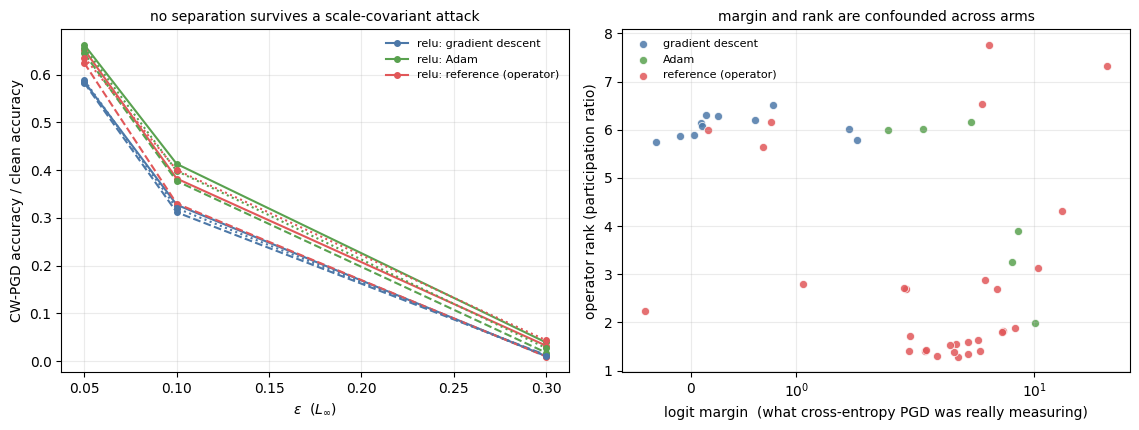

CW-PGD accuracy as a fraction of clean accuracy, best hyper per arm (interpolating only)
   arch   arm       hyper   clean  eps=0.05   eps=0.1   eps=0.3    margin   rank
   relu    gd         0.1   0.532    58.5%    32.7%     1.1%      1.57   5.78
   relu  adam       0.003   0.642    66.2%    41.3%     3.9%     10.11   1.98
   relu    op   (1.0, 20)   0.561    65.2%    38.2%     3.3%      5.02   1.64
  crelu    gd        0.03   0.517    58.2%    31.2%     1.3%      0.78   6.52
  crelu  adam       0.001   0.588    64.4%    37.7%     1.8%      4.62   6.17
  crelu    op  (10.0, 20)   0.609    62.4%    33.0%     1.0%     14.06   4.31
  leaky    gd         0.1   0.534    58.8%    32.0%     1.1%      1.50   6.01
  leaky  adam       0.003   0.660    65.7%    39.8%     2.8%      8.19   3.90
  leaky    op   (1.0, 50)   0.583    63.6%    40.0%     4.4%      6.36   2.70


In [31]:
rob = analysis.robustness_sweep(runs, eps=(0.05, 0.1, 0.3), restarts=2)
f = analysis.fig_robustness(rob, eps=(0.05, 0.1, 0.3)); save(f, 'fig_robustness'); plt.show()
print('CW-PGD accuracy as a fraction of clean accuracy, best hyper per arm (interpolating only)')
print(f'{"arch":>7}{"arm":>6}{"hyper":>12}{"clean":>8}' + ''.join(f'{"eps="+str(e):>10}' for e in (0.05,0.1,0.3))
      + f'{"margin":>10}{"rank":>7}')
for arch in ('relu','crelu','leaky'):
    for arm in ('gd','adam','op'):
        g = [r for r in rob if r['arch']==arch and r['arm']==arm and r['train_acc']>0.999]
        if not g: continue
        b = max(g, key=lambda r: r['clean'])
        print(f'{arch:>7}{arm:>6}{str(b["hyper"]):>12}{b["clean"]:>8.3f}'
              + ''.join(f'{b[f"ratio_{e}"]:>9.1%}' for e in (0.05,0.1,0.3))
              + f'{b["margin"]:>10.2f}{b["pr"]:>7.2f}')

**The corrected picture: there is no separation.** As a fraction of clean accuracy the three
arms lie within a few points of each other at every radius, and on CReLU *Adam is the least*
robust. The tenfold gap is gone. Two further checks confirm the diagnosis rather than the
measurement:

*Rescaling.* Dividing every layer by a constant leaves the decision boundary of a bias-free
homogeneous network **exactly** unchanged, so true robustness cannot move. Under the cross-entropy
attack it moves a great deal; under CW it does not (0.019 vs 0.019 on the ReLU reference, 0.021 vs
0.022 on CReLU). The effect was in the attack, not the geometry.

*What the confound actually was.* Not rank and margin directly --- those correlate only weakly
($\rho = -0.23$). The cross-entropy attack failed on the **high-margin** cells, and the arms differ
in margin by two orders of magnitude, so the apparent *arm* separation was a margin effect. What
rank is entangled with is the operator norm: $\rho(\text{rank}, \|P\|_F) = -0.82$, low rank going
with a *large* Jacobian. The cell below reports what is left of the rank correlation once the
attack is fixed, and how much of it is really a norm effect.

In [32]:
from scipy.stats import spearmanr, rankdata
sub = [r for r in rob if r['train_acc'] > 0.999 and r['pr'] == r['pr']]
R = lambda k: rankdata([r[k] for r in sub])
def partial(a, b, c):
    A, B, C = R(a), R(b), R(c)
    ra = A - np.polyval(np.polyfit(C, A, 1), C); rb = B - np.polyval(np.polyfit(C, B, 1), C)
    return np.corrcoef(ra, rb)[0, 1]
print(f'{len(sub)} interpolating cells, CW attack')
for e in (0.05, 0.1, 0.3):
    print(f'  eps={e}:  Spearman(rank, ratio) = {spearmanr(R("pr"), R(f"ratio_{e}")).statistic:+.3f}'
          f'   partial|clean = {partial("pr", f"ratio_{e}", "clean"):+.3f}')
print(f'\n  the confound:  Spearman(rank, margin)  = {spearmanr(R("pr"), R("margin")).statistic:+.3f}')
print(f'                 Spearman(rank, ||P||_F) = {spearmanr(R("pr"), R("fro")).statistic:+.3f}')

63 interpolating cells, CW attack
  eps=0.05:  Spearman(rank, ratio) = -0.480   partial|clean = -0.448
  eps=0.1:  Spearman(rank, ratio) = -0.481   partial|clean = -0.437
  eps=0.3:  Spearman(rank, ratio) = -0.598   partial|clean = -0.584

  the confound:  Spearman(rank, margin)  = -0.229
                 Spearman(rank, ||P||_F) = -0.822


**What survives, stated carefully.**

*The arm-level claim is dead.* At each arm's best hyperparameter the three coincide --- 58--66% of
clean accuracy at $\epsilon = 0.05$ and 31--42% at $\epsilon = 0.1$, with the ordering not even
consistent across architectures. The tenfold gap does not exist. This was the claim that mattered
and it is gone.

*A cell-level rank correlation does partially survive, and should not be leaned on.* Over the 63
interpolating cells, $\rho(\text{rank}, \text{ratio}) = -0.48$ to $-0.59$ under the CW attack
(down from $-0.64$), and $-0.44$ to $-0.58$ controlling for clean accuracy. But controlling for the
operator norm alone collapses it to $-0.19$ to $-0.27$, and controlling for all three of clean
accuracy, margin and norm brings it back to $\approx -0.49$. Partial correlations that swing that
much with the control set are not measuring a stable effect: with $n = 63$, three correlated
predictors, and a badly unbalanced design (30 operator cells against 6 Adam and 11 gd), this sample
cannot separate rank from norm. **The honest statement is that we do not know**, and the experiment
that would settle it is not one we should run on the strength of this.

*Delayed robustness* (5.5) is likewise inflated: under CW it is weak at $\epsilon = 0.3$
(0.021 $\to$ 0.098 over 275k steps) and flat at $\epsilon = 0.1$.

**One thing genuinely learned, in the negative direction.** $\|P(x)\|_F$ --- which *is* the input
Jacobian norm here, since $f(x) = P(x)x$ --- is 4--20$\times$ **larger** for the reference than for
gradient descent (200--1050 against 31--55). So whatever the reference is doing, it is not
Jacobian-norm regularisation, the standard route to robustness in the literature. That is worth
one sentence in the paper and nothing more.

**The methodological lesson, which is the part worth keeping.**

1. A saturating attack objective inverts the measured ordering, and it does so *in favour of
   whichever model has the largest logits* --- systematically, not randomly.
2. The standard masking control --- more steps, more restarts --- **cannot detect it.** We ran it
   (10 $\to$ 50 $\to$ 200 steps, 5 restarts, all within 0.01) and it came back clean on a result
   that was entirely artefactual.
3. The controls that do work are cheap: attack with a scale-covariant objective, and rescale the
   network to check that a transformation which provably cannot change the decision boundary does
   not change the measurement.
4. Bias-free homogeneous networks make this acute, because the logit scale is unbounded along any
   interpolating trajectory and differs by orders of magnitude between optimisers. Any robustness
   number reported on such a model without a scale control should be disbelieved --- including the
   ones we reported.

The literature this was checked against: low-rank weights and robustness is established and
direction-dependent, and Jacobian-norm regularisation is a standard robustness method. Even had
the effect been real, the ingredient would not have been new.

---
# Part 6 --- Summary: what separates what

Collecting every metric measured, with the direction and what it distinguishes.

In [33]:
rows = [
 ('cos_op (deflection)',        '0.22-0.25', '0.07-0.12', '0.83-0.90', 'all three (inversely to accuracy)'),
 ('cos_w',                      '0.12-0.27', '0.02-0.07', '0.38-0.50', 'all three'),
 ('reachability alpha',         '1.000',     '0.996-1.000','1.000',    'nothing (see 2.1)'),
 ('operator rank (PR)',         '5.7-6.6',   '2.1-3.9',   '6.0-6.8',   'Adam  (but see 5.7: varies within arm)'),
 ('ker(M) fraction',            '0.000',     '~0.16',     '0.000',     'Adam (by construction)'),
 ('gate churn (late)',          '0.0004-9',  '0.001-0.024','0.015-0.030','gd only -- see Part 7'),
 ('switching (gating used)',    '0.99-1.00', '0.91-1.00', '0.71-0.76', 'operator'),
 ('region concentration',       '~+0.09',    '~+0.09',    '+0.17-0.25','operator'),
 ('rescale fraction',           '1-2%',      '-',         '26-71%',    'operator'),
 ('CW-PGD 0.05 / clean (5.7)',  '57-60%',    '55-67%',    '57-65%',    'NOTHING -- arms coincide'),
 ('test accuracy',              '0.51-0.53', '0.61-0.66', '0.55-0.58', '-'),
]
w=(26,11,11,11)
print(f"{'metric':<26}{'gd':>12}{'Adam':>12}{'operator':>12}   separates")
print('-'*96)
for r in rows: print(f'{r[0]:<26}{r[1]:>12}{r[2]:>12}{r[3]:>12}   {r[4]}')
print()
print('Each column is the arm at its best hyperparameter by stable_test. Two cautions:')
print(' - operator rank varies more WITHIN an arm (across its lr / k grid) than between arms;')
print(' - the robustness row was reported as a 10x separation until the attack was fixed (5.7).')

metric                              gd        Adam    operator   separates
------------------------------------------------------------------------------------------------
cos_op (deflection)          0.22-0.25   0.07-0.12   0.83-0.90   all three (inversely to accuracy)
cos_w                        0.12-0.27   0.02-0.07   0.38-0.50   all three
reachability alpha               1.000 0.996-1.000       1.000   nothing (see 2.1)
operator rank (PR)             5.7-6.6     2.1-3.9     6.0-6.8   Adam  (but see 5.7: varies within arm)
ker(M) fraction                  0.000       ~0.16       0.000   Adam (by construction)
gate churn (late)             0.0004-9 0.001-0.024 0.015-0.030   gd only -- see Part 7
switching (gating used)      0.99-1.00   0.91-1.00   0.71-0.76   operator
region concentration            ~+0.09      ~+0.09  +0.17-0.25   operator
rescale fraction                  1-2%           -      26-71%   operator
CW-PGD 0.05 / clean (5.7)       57-60%      55-67%      57-65%   NOTHI

**The pattern.** Several measures separate the **reference from both baselines** (switching,
concentration, rescaling, $\cos_{op}$) and several separate **Adam from both** ($\ker M$ fraction).
But **nothing orders all three arms by clean generalisation.** In particular nothing here explains
the gd-vs-Adam gap (0.51 vs 0.64): on concentration the two are indistinguishable ($t = 0.1$), and
on switching they differ in the wrong direction.

$\cos_{op}$ is the only measure that cleanly separates all three, and it orders them **inversely**
to accuracy --- and 5.6 then shows that inversion is not causal, since degrading $\cos_{op}$
inside the operator family does not improve anything.

**Two revisions this table needed, both from controls run after it was first written.**

*Gate churn.* The row originally read "gd and the reference both low, Adam highest", supporting a
prediction that operator-faithful rules carry no gate pressure. Measured late-training churn is
gd 0.0004--0.0009, Adam 0.0012--0.0237, reference 0.0149--0.0296: the reference churns *most* on
CReLU and leaky. The prediction survives for gradient descent only, and is probably confounded with
step size --- see Part 7.

*Robustness.* This row first read "gd 2.1--3.1%, Adam 18.5--32.6%, reference 24.3--32.0%" --- the
largest separation in the table --- and was traced to an attack that fails against high-margin
networks (5.7). Under a scale-covariant attack the arms coincide. Nothing was added to the table by
robustness, and the rank correlation it appeared to support was rank correlating with *logit
margin*, which is what broke the attack.

## 6.1 Claims withdrawn during this work

Listed explicitly because each was reported before its control was run.

| claim | why it fell |
|---|---|
| "Adam wins by pruning (58% dead units)" | peak-selector artefact; the generalising Adam has 8.8% |
| "Leaky dissociates pruning from accuracy" | compared peak-selected ReLU against stable-selected leaky |
| "The operator arm wins on ReLU" | selected by one estimator, scored by another |
| U-shaped $k$-dial / optimal amount of bias | confounded with step size; $k{=}1,2$ never fit |
| "Low region density at the data predicts generalisation" | refuted paired across 24 planes; sign flips by architecture |
| "Adam rescales rather than redirects" | true at one point, not along trajectories |
| "Regions migrate away from the data" | density *decreases* with distance for all three arms |
| Operator-level faithfulness explains the bias | Adam least faithful, generalises best |
| Test-accuracy grokking | no weight decay / standard init: the regime where it is not predicted |
| "$\alpha$ collapses to 0.12--0.23 along Adam's path" | peak-selector artefact; stable-selected Adam has $\alpha=0.996$--$1.000$, same as the others |
| "gd and the reference both show low gate churn" | holds for gd only; the reference churns *most* on CReLU and leaky (Part 7) |
| **"gd has ~zero adversarial robustness, the other arms 20--32%"** | cross-entropy attack saturating against high-margin networks; under a scale-covariant attack the arms coincide (5.7) |
| **"Operator rank predicts robustness ($\rho=-0.64$)"** | rank correlates with *logit margin*, which is what broke the attack; the correlation is between rank and saturation |
| **"Delayed robustness reproduces here"** | same attack; weak at $\epsilon{=}0.3$ and flat at $\epsilon{=}0.1$ under CW (5.5, 5.7) |

**Four methodological lessons.**

1. A best-over-grid statistic must not be read before the grid is complete *and* must bracket each
   method's optimum.
2. A run must be **selected and scored by the same estimator** --- mixing them produced three of
   the errors above.
3. **A control that cannot fail is not a control.** The gradient-masking check we ran (more steps,
   more restarts) is incapable of detecting saturation-induced masking, so its clean result carried
   no information. Before trusting a control, ask what result would have made it fire.
4. **Check a new correlate against the known literature early.** The robustness artefact was found
   only because the question "is low-rank $\to$ robustness already known?" prompted a check of
   the Jacobian-norm connection --- which led to measuring the margin, which is what exposed it.
   The novelty check and the correctness check turned out to be the same check.

---
# Part 7 --- Where this leaves us

**What is solid.** A canonical reference step for factored models, with two hyperparameter-free
diagnostics; the identity $\mathrm{GD} = k{=}1$ Krylov truncation; the reference as
$-\eta(M^\top M)^{+}\nabla_W\mathcal L$, coinciding with the natural gradient for whitened deep
linear. Empirically: all arms interpolate; generalisation orders gd $<$ reference $<$ Adam in all
three architectures; the reference performs at k-NN level; and it is distinguished from both
baselines by concentrating regions on the data and under-using its gating.

**What is missing.** Any account of *why* Adam generalises better. Every structural measure either
fails to separate gd from Adam, or orders the three arms inconsistently with accuracy.

**One explanation eliminated, not merely unsupported.** $\cos_{op}$ orders all three arms inversely
to accuracy (Part 6), which invites the reading that *unfaithfulness is the useful ingredient*.
Operator momentum (5.6) tests that directly: it lowers $\cos_{op}$ from 0.80--0.88 to 0.09--0.30
inside the operator family, holding target, solver, $\eta$ and seeds fixed, and accuracy does not
improve at any $\beta$ --- it falls by up to 0.07. The inverse ordering is a correlation across
arms, not a mechanism.

**One apparent explanation withdrawn.** Adversarial robustness looked like the sharpest separation
in the report and turned out to be an attack artefact (5.7). It is worth being explicit that this
removes the only *new positive* empirical result added since the last revision; the report is
stronger for the controls but has less in it.

**A prediction that failed, recorded rather than quietly dropped.** $\Delta_\star$ prescribes a
change to $P(x)$ *given the current gate pattern* and says nothing about the pattern itself, so an
operator-faithful step carries no explicit term pushing the gates to reorganise; gradient descent
inherits the same silence, since $\Delta W^{\mathrm{GD}} = M^\top\Delta_\star$. I predicted low gate
churn for both. Measured late-training churn at each arm's best hyperparameter:

| | gd | Adam | reference |
|---|---|---|---|
| ReLU | 0.0004 | 0.0237 | 0.0178 |
| CReLU | 0.0009 | 0.0012 | 0.0149 |
| leaky | 0.0005 | 0.0082 | 0.0296 |

The prediction holds for gd --- near zero, 20--60$\times$ below every other arm --- and **fails for
the reference**, which churns *most* on CReLU and leaky. The likely confound is step magnitude
rather than direction: the reference's best $\eta$ is 0.5--10 against gd's 0.03--0.1, and a larger
weight displacement flips more pre-activations regardless of what the rule asks for.

**The strongest remaining leads, in order.**
1. **Depth.** Every number in this report is at depth 8, while the framework is motivated by the
   operator/parameter mismatch *growing with depth*. That is a gap between the motivation and the
   evidence, it is the cheapest thing left to close, and it is the most likely source of a positive
   result: either the mismatch grows as the theory predicts, or it does not and that is more
   interesting still.
2. **A preconditioned baseline.** The reference *is* a preconditioner,
   $-\eta(M^\top M)^{+}\nabla_W\mathcal L$, and with only gd and Adam as comparators the question
   "is this K-FAC / Shampoo / Muon in disguise?" is open. Part of it is answerable in theory, given
   the natural-gradient coincidence already established.
3. **The switch experiment (5.4)** remains the clearest positive result: Adam's contribution is
   front-loaded and largely irreversible, and on CReLU the Adam$\to$reference mixture beats both
   pure arms ($0.660 \pm 0.008$). Whatever creates the advantage happens early.
4. **Norm-matched arms.** Several cross-arm comparisons --- churn above, plausibly region
   concentration, and in hindsight everything that logit scale touches --- are confounded with the
   displacement size each rule takes at its best hyperparameter. A comparison at matched
   $\|\Delta W\|$ would make those claims about *direction* rather than *magnitude*.

**On scale.** 5.7 is the second time a result has turned on a quantity that grows without bound in
a bias-free homogeneous network (the first was the LSQR divergence in 1.3, where $\|x\|$ reached
$2.9\times10^9$ with the residual unchanged to seven digits). Scale-invariance is worth treating as
a standing check on any new measurement here, not a special precaution.

---
# Part 8 --- Operator-space trajectories: the complete grid

**Motivation.** Everything in Parts 2--7 is a scalar summary of a trajectory --- a cosine, a rank,
an accuracy. This section shows the trajectories themselves, in the space the framework is about.
It is the previous submission's two-dimensional figure, widened from one architecture and two
initialisations to every combination we run.

**Depth 32, deliberately.** The gap between an optimiser's weight step and the operator step it
induces is what this framework measures, and that gap grows with depth: the depth sweep gives
$\cos_{op}$ for gradient descent falling from 0.40--0.48 at $L{=}2$ to 0.20--0.29 at $L{=}4$,
and for Adam from 0.19--0.21 to 0.11--0.14. A shallow panel would show the arms nearly on top of
one another.

*Read the operator arm's own $\cos_{op}$ differently from the others.* Gradient descent **is**
the $k{=}1$ truncation exactly (1.2), so its cosine measures the parameterisation bias. The
operator arm is the $k{=}50$ truncation, while the probe's target is solved to $k{=}3000$ with
damping, so its cosine measures **how much of the reference fifty Krylov iterations capture** ---
a solver-convergence diagnostic, not a property of the framework. It rises to 1.0000 with $k$ at
every depth tested (ReLU $L{=}32$: 0.71 at $k{=}50$, 0.88 at 200, 0.978 at 1000, 0.9999 at 3000),
so its apparent decay with depth is a fixed-budget artefact: a deeper step map needs more
iterations. See 1.3 for why raising $k$ indefinitely is not the answer either. $L{=}32$ is where the bias is worth looking at ---
and it also separates the two effects the framework claims are distinct, since `he` and `xavier`
at that depth are poorly conditioned while `crelu` with `looks_linear` is conditioned by
construction at any depth.

**The construction, and why it is in operator space.** The model is a bias-free chain of depth $L$
and width $h$ mapping two features to one output. However large the weight space is, the operator
$P(x)$ has exactly **two** components, so its path can be drawn exactly. The loss

$$\mathcal L(P) = \tfrac1N \lVert X P^\top - y \rVert^2$$

is quadratic in $P$, so the contours are exact ellipses and $P^\star$ is the ordinary
least-squares solution.

A weight-space version of this figure cannot work, and it is worth saying why. A model whose
*weight* space is two-dimensional has a rank-one step map $M$, so $M^{+} \propto M^\top$ and
gradient descent coincides with the reference **identically** --- measured at
$\cos = 1.0000000000$ in 1.2. No parameterisation effect can appear. With $L$ layers feeding a
two-dimensional operator, $M$ has rank two and the rules separate. Every difference visible in
these panels is attributable to *how each rule turns a weight step into an operator step*, because
all eight descend the same quadratic in $P$.

**Definitions.** Each panel is one (architecture, initialisation) pair; each coloured path is one
optimiser; the solid dot is the initialisation and the star is $P^\star$. `linear` and `fgln` have
input-independent gates, so $P$ is a single $1\times2$ matrix and the path is exact. `relu`,
`leaky` and `crelu` have input-dependent gates, so the path is the data-averaged operator
$\mathbb E_x[P(x)]$, and each such panel is annotated with the spread of $P(x)$ across inputs ---
because an average cannot distinguish "every input sees the same map" from "the average of two
very different maps", and the second is what a nonlinear network is *for*. On those panels the
contours are a frame of reference, not the model's true loss surface.

**Fairness.** Each arm's learning rate is swept per panel and the rate reaching the lowest final
operator loss is the one drawn. Without this the figure would compare tuning luck: the arms differ
in natural step scale by orders of magnitude, and the reference has no learning rate at all --- it
has a target size $\eta$. The rules are `exp.step_for`, the same implementations the main
experiments use, with the comparators checked against their published forms
(`studies/tests_baselines.py`).

In [ ]:
import traj_grid, importlib
importlib.reload(traj_grid)
DEPTH, HIDDEN = 32, 32          # deep: this is where the parameterisation bias is largest
data, Pstar, Xt, yt = traj_grid.build(depth=DEPTH, hidden=HIDDEN, n=128, steps=300, dev='cpu')
f = traj_grid.figure(data, Pstar, Xt, yt, DEPTH, HIDDEN)
save(f, 'fig_traj_grid_L32'); plt.show()

In [ ]:
print('chosen learning rate and final operator loss per panel')
print(f'{"arch":>8}{"init":>14}' + ''.join(f'{a:>12}' for a in traj_grid.ARMS))
for arch in traj_grid.ARCHS:
    for init in traj_grid.INITS:
        row = f'{arch:>8}{init:>14}'
        for arm in traj_grid.ARMS:
            d = data.get((arch, init, arm))
            row += f'{"--":>12}' if d is None else f'{d["lr"]:>6g}/{d["end"]:<5.0e}'
        print(row)